# Observational Techniques in Astrophysics (2024-2025)

### Spectroscopy

This notebook contains the spectroscopic reduction, wavelength calibration, and radial-velocity analysis of the M1 dataset.


Spectroscopic data reduction shares several steps with photometric reduction, including bias, dark, and flat-field corrections. The main additional step is the calibration of the wavelength axis, which allows emission lines to be identified and their radial velocities to be measured.

In this analysis, the final kinematic measurements are obtained from several spatial regions along the slit. Line positions are determined visually, and the corresponding radial velocities are combined using their measurement uncertainties.


## Data

The dataset used in this analysis consists of spectroscopic observations obtained with CAFOS at Calar Alto. The reduction is performed using the FITS files stored in the local data directory.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

from astropy.io import fits
from scipy import stats
from scipy.signal import find_peaks


## Part 1: Preprocessing

The raw images are corrected for the main instrumental effects using a master bias, a zero dark frame, and a master flat.


We first define a function to read FITS images together with their headers.


In [2]:
def read_data(fname):
  hdu = fits.open(fname)
  data = hdu[0].data
  header = hdu[0].header
  hdu.close()
  return data.astype(np.float64),header


We also define a small helper function to display 2D images.


In [3]:
def show_image(data,vmin=None,vmax=None):
  if vmin is None:
    vmin = np.nanpercentile(data,1)
  if vmax is None:
    vmax = np.nanpercentile(data,99)

  plt.figure(figsize=[6,6],dpi=100)
  plt.imshow(data,vmin=vmin,vmax=vmax,origin='lower',interpolation=None,
             cmap="gray")
  plt.colorbar()
  plt.tight_layout()
  plt.show()
  return None


We now define a function to read all FITS files in a directory.


In [4]:
def read_set(f_base):
  f_names = os.listdir(f_base)
  data_list = []
  texp_list = []
  for f_name in f_names:
    if f_name[-5:] =='.fits':   # Check that the file ends with ".fits"
      data,header = read_data(f_base+f_name)
      texp = header['EXPTIME']
      data_list.append(data)
      texp_list.append(texp)
  return np.array(data_list),np.array(texp_list)


The calibration-lamp files are identified from their FITS headers.


In [5]:
def find_arcs(f_base):
    arcs_list = []
    f_names = os.listdir(f_base)
    for f_name in f_names:
        if f_name[-5:] =='.fits':
            data,header = read_data(f_base+f_name)
            if header["OBJECT"].startswith("[arc]"):
                print("Calibration-lamp file:", f_name)
                arcs_list.append(data)
    return np.array(arcs_list)


In [6]:
base = "D:\\Documents\\Jupyter Notebooks\\TEA 2025\\Proyecto\\M1\\Datos\\M1 Calar Alto 180216"

base_flats_arcs = base+"/flat_arc_G200/"
arcs = find_arcs(base_flats_arcs)


Calibration-lamp file: cali_0033.fits
Calibration-lamp file: cali_0034.fits
Calibration-lamp file: cali_0035.fits


### Master bias

The master bias is computed as the pixel-by-pixel median of the available bias frames.


Exposure time: 0.0 s


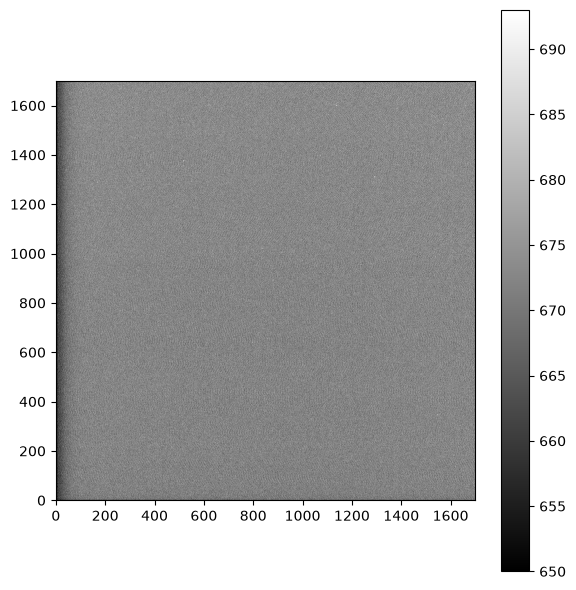

In [7]:
base_bias = base+"/bias/"
bias,_ = read_set(base_bias)

print("Exposure time:", _[0], "s")
show_image(bias[0])


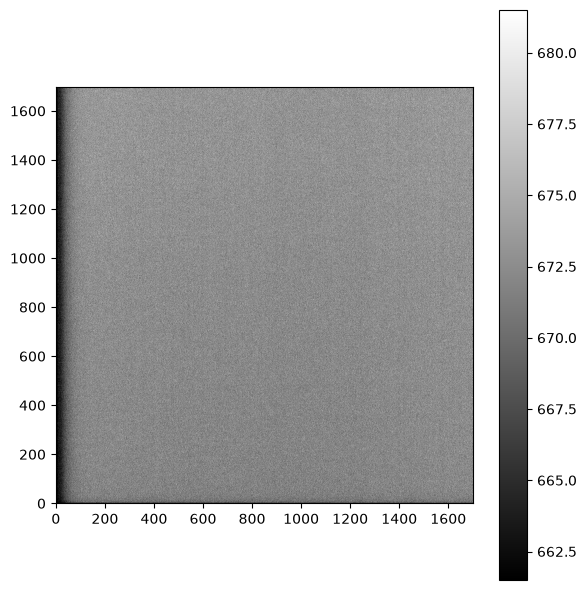

In [8]:
master_bias = np.nanmedian(bias,axis=0)
show_image(master_bias)


In [9]:
print("Readout noise:",np.nanstd(master_bias[1:,2:]),"counts")


Readout noise: 4.906068509023343 counts


### Dark frame

CAFOS is cooled with liquid nitrogen, so the dark current is treated as negligible for this dataset. We therefore use a zero dark frame.


In [10]:
master_dark = np.zeros_like(master_bias)


### Master flat

Spectroscopic flats contain a wavelength-dependent response. The flats are normalized along the spatial direction before combining them.


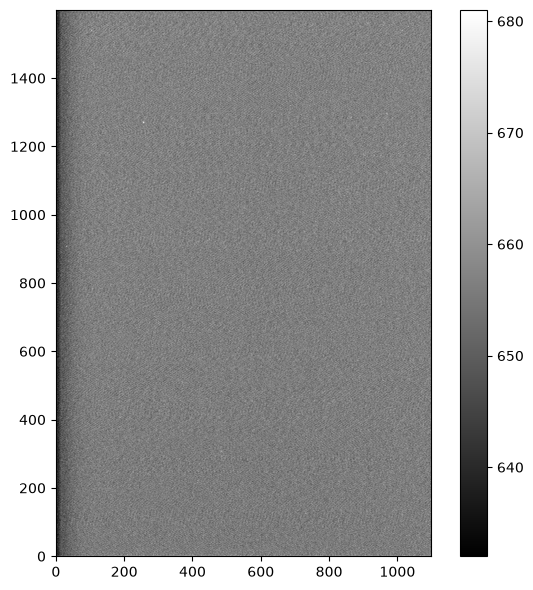

In [11]:
base_flat = base+"/flat_arc_G200/"
flats,_ = read_set(base_flat)
show_image(flats[0])


In [26]:
master_bias = master_bias[:1600, :1100]
master_dark = master_dark[:1600, :1100]


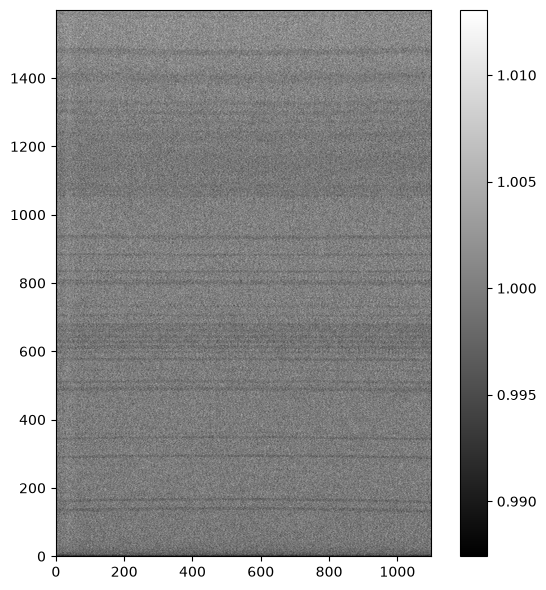

In [27]:
for i,flat in enumerate(flats):
  flat = flat - master_bias
  flats[i] = flat/np.nanmedian(flat,axis=0)
master_flat = np.nanmedian(flats,axis=0)
show_image(master_flat)


In [28]:
master_flat_new = master_flat.copy()
iden = np.where(master_flat_new<0.1)
master_flat_new[iden] = 0.1


## Part 2: Wavelength Calibration

The wavelength calibration maps detector pixels to physical wavelengths. This is done by identifying known emission lines in an arc-lamp spectrum and fitting their laboratory wavelengths as a function of pixel position.


We load one of the calibration-lamp images.


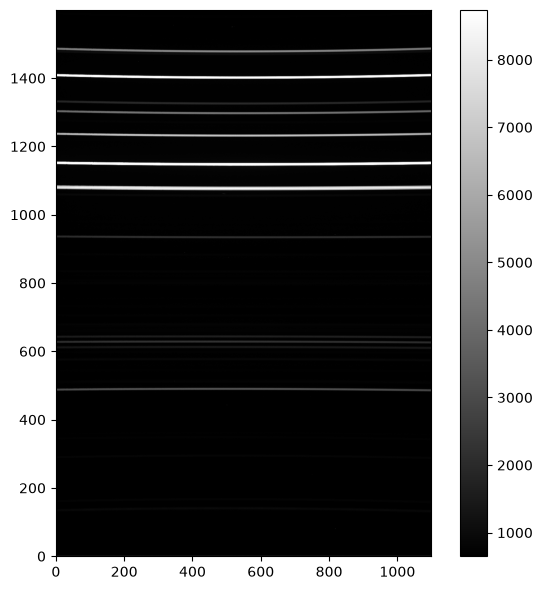

In [29]:
show_image(arcs[0])


A one-dimensional arc spectrum is obtained by averaging a narrow spatial region of the lamp image.


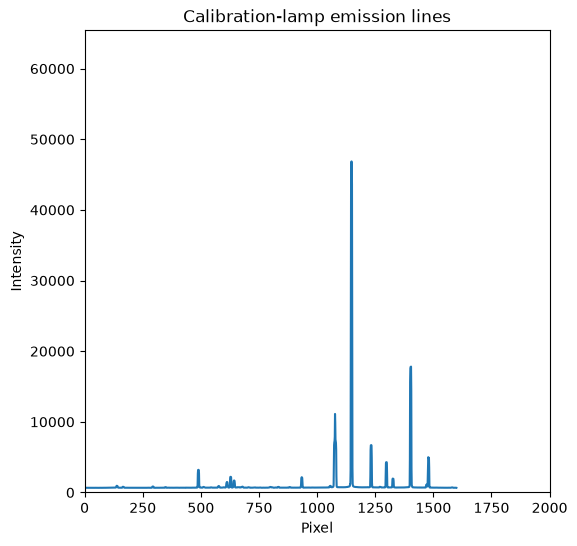

In [30]:
arc_spec = arcs[0][:,720:727].mean(axis=1)

plt.figure(figsize=[6,6],dpi=100)
plt.plot(arc_spec)
plt.xlabel("Pixel")
plt.ylabel("Intensity")
plt.title("Calibration-lamp emission lines")
plt.xlim(0,2000)
plt.ylim(0,65400)
plt.show()


We identify the emission-line peaks using `find_peaks`.


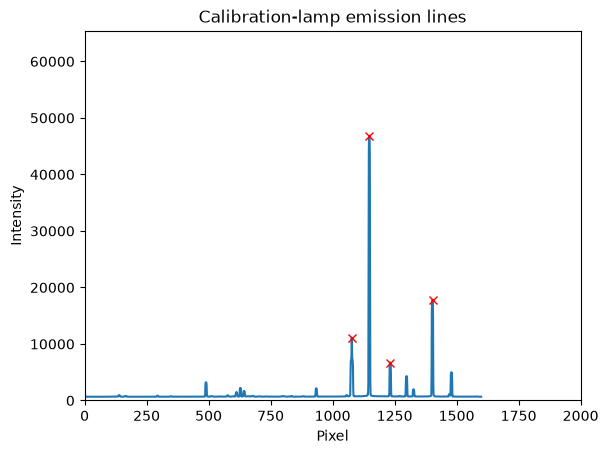

array([1077, 1148, 1233, 1404])

In [31]:
prominence = 5000
peaks, _ = find_peaks(arc_spec, prominence=prominence)

plt.plot(arc_spec)
plt.plot(peaks, arc_spec[peaks], "rx")
plt.xlabel("Pixel")
plt.ylabel("Intensity")
plt.title("Calibration-lamp emission lines")
plt.xlim(0,2000)
plt.ylim(0,65400)
plt.show()

peaks


# Calar Alto calibration-lamp reference: http://w3.caha.es/CAHA/Instruments/CAFOS/comp.html

The wavelengths corresponding to the identified peaks are shown below.

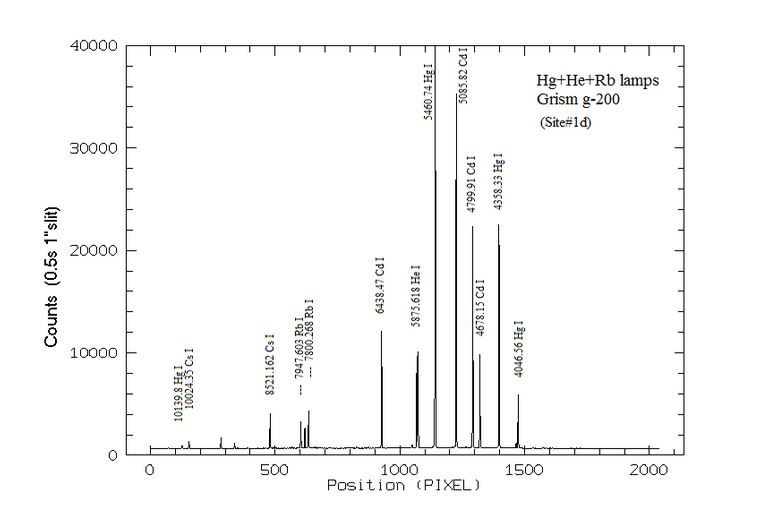


In [32]:
wavelenghts = np.array([
                          5875.618, # He I
                          5460.74,  # Hg I
                          5085.82,  # Cd I
                          4358.33,  # Hg I
])


We fit a linear relation between the detector pixel positions and the laboratory wavelengths.


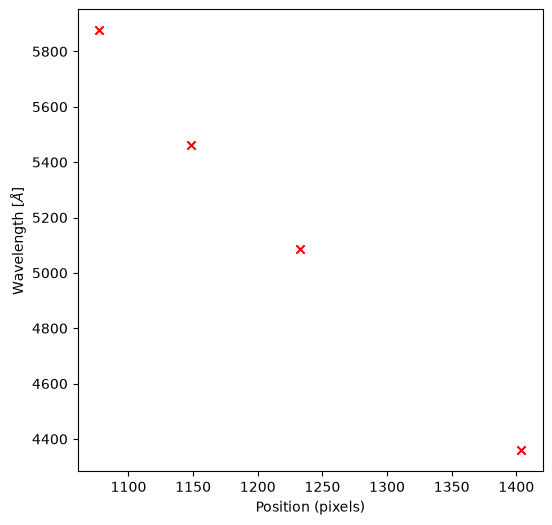

In [33]:
plt.figure(figsize=[6,6],dpi=100)
plt.scatter(peaks,wavelenghts, marker="x",color='r')
plt.xlabel("Position (pixels)")
plt.ylabel(r"Wavelength $[\AA]$")
plt.show()


Slope: -4.56260
Intercept: 10740.96664
R-squared: 0.99554
P-value: 0.00223


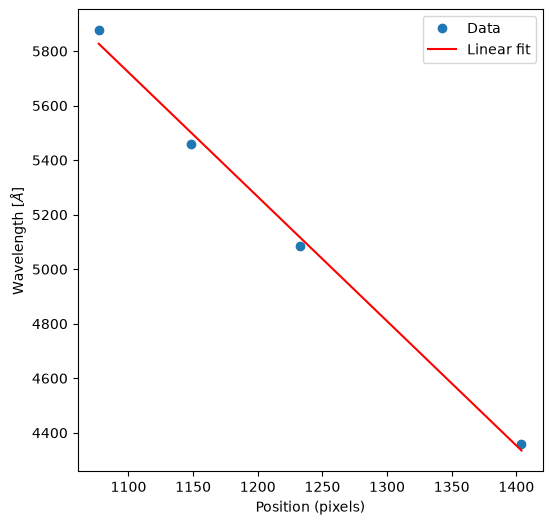

In [34]:
slope, intercept, r_value, p_value, std_err = stats.linregress(peaks, wavelenghts)
print(f"Slope: {slope:.5f}")
print(f"Intercept: {intercept:.5f}")
print(f"R-squared: {r_value**2:.5f}")
print(f"P-value: {p_value:.5f}")

fit_line = slope * np.array(peaks) + intercept

plt.figure(figsize=[6,6])
plt.plot(peaks, wavelenghts, 'o', label='Data')
plt.plot(peaks, fit_line, 'r', label='Linear fit')
plt.xlabel("Position (pixels)")
plt.ylabel(r"Wavelength $[\AA]$")
plt.legend()
plt.show()

wavelength_array = slope * np.arange(len(arc_spec)) + intercept


The fitted relation is applied to the detector axis to obtain the calibrated wavelength array.


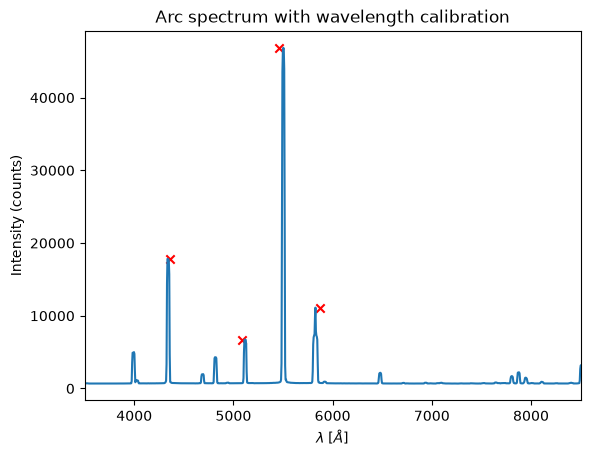

In [35]:
plt.plot(wavelength_array, arc_spec)
plt.scatter(wavelenghts,arc_spec[peaks], marker="x",color='r')
plt.xlim(3500,8500)
plt.xlabel(r"$\lambda \; [\AA]$")
plt.ylabel("Intensity (counts)")
plt.title("Arc spectrum with wavelength calibration")
plt.show()


### Note on flux calibration

The flux-calibration section present in the original notebook is not used by the final radial-velocity analysis, so it has been omitted from the final workflow.


## Part 3: Nebular Spectrum Reduction

We now load the nebular spectrum and apply the bias, dark, and flat-field corrections.


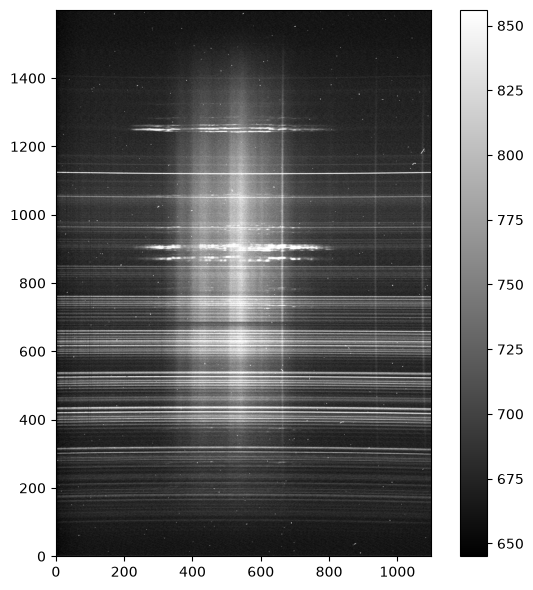

In [36]:
f_neb = base+'/UAM_0017.fits'
neb_spec_raw,header_neb = read_data(f_neb)
texp_neb = header_neb['EXPTIME']
show_image(neb_spec_raw)


In [37]:
neb_spec_red = neb_spec_raw - master_bias - master_dark
neb_spec_red = neb_spec_red/master_flat_new
neb_spec_red /= texp_neb


### Integrated nebular spectrum

The nebular region is integrated over the central part of the slit, while a nearby spatial region is used to estimate the sky contribution.


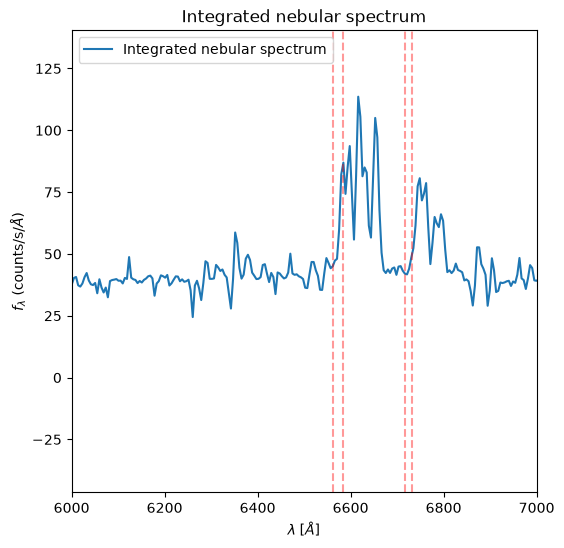

In [38]:
neb_spec_full = neb_spec_red[:,350:700]
sky_neb_spec = neb_spec_red[:,0:350]
neb_spec_full = np.sum(neb_spec_full, axis=1)
sky_neb_spec = np.sum(sky_neb_spec, axis=1)
neb_spec_full = neb_spec_full - sky_neb_spec

plt.figure(figsize=[6,6],dpi=100)
plt.plot(wavelength_array,neb_spec_full,label='Integrated nebular spectrum')
plt.xlabel(r'$\lambda \; [\AA]$')
plt.ylabel(r'$f_{\lambda}$ (counts/s/$\AA$)')
plt.title('Integrated nebular spectrum')
plt.axvline(6563,color='r',ls='dashed',alpha=0.4)
plt.axvline(6717,color='r',ls='dashed',alpha=0.4)
plt.axvline(6731,color='r',ls='dashed',alpha=0.4)
plt.axvline(6583,color='r',ls='dashed',alpha=0.4)
plt.xlim([6000,7000])
plt.legend()
plt.show()


## Part 4: Radial Velocities by Spatial Region

The final analysis uses manually identified line shifts for seven spatial regions along the slit. A fixed uncertainty of 5 Å is assigned to the observed wavelength measurement, and the individual velocities are combined using inverse-variance weighting.


### Final analysis: line positions measured visually


### Region 1


In [39]:
neb_spec_360 = neb_spec_red[:,360:366]
sky_spec_6 = neb_spec_red[:,1000:1006]
sky_spec_6 = np.sum(sky_spec_6, axis=1)
neb_spec_360 = np.sum(neb_spec_360,axis=1)
neb_spec_360 = neb_spec_360 - sky_spec_6
VELOCIDADES_POR_PIXEL = []


Plot saved: D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion\spectrum_pixel_360_4500-6000.png


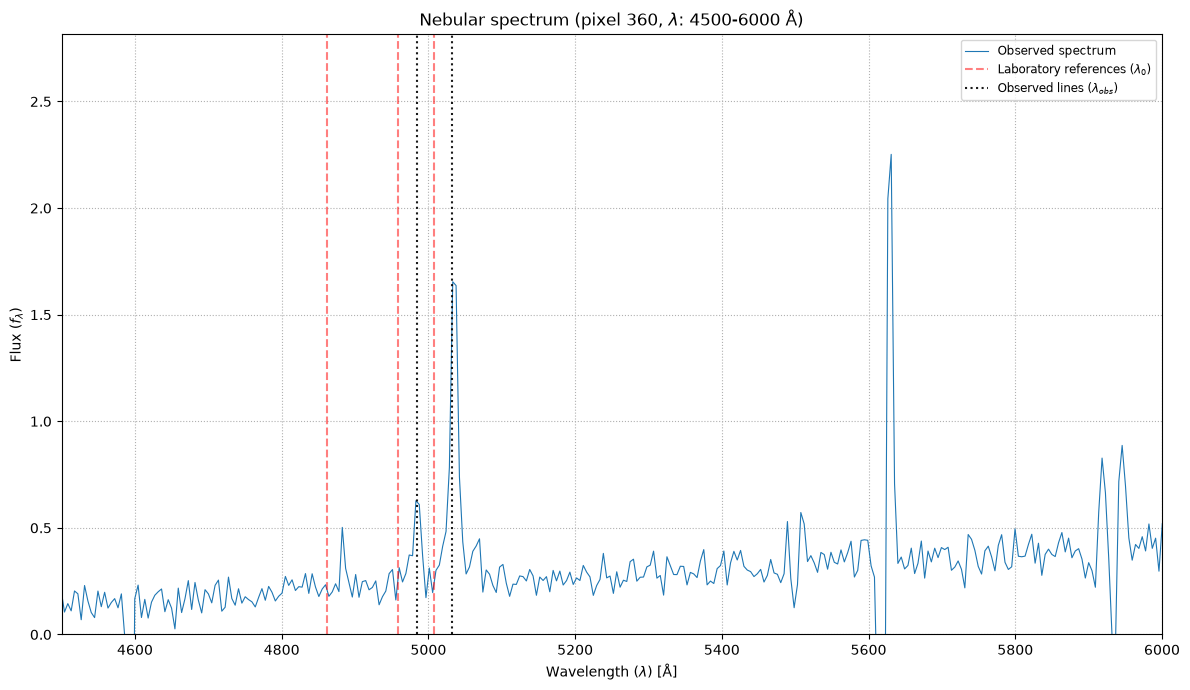

Plot saved: D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion\spectrum_pixel_360_6000-7500.png


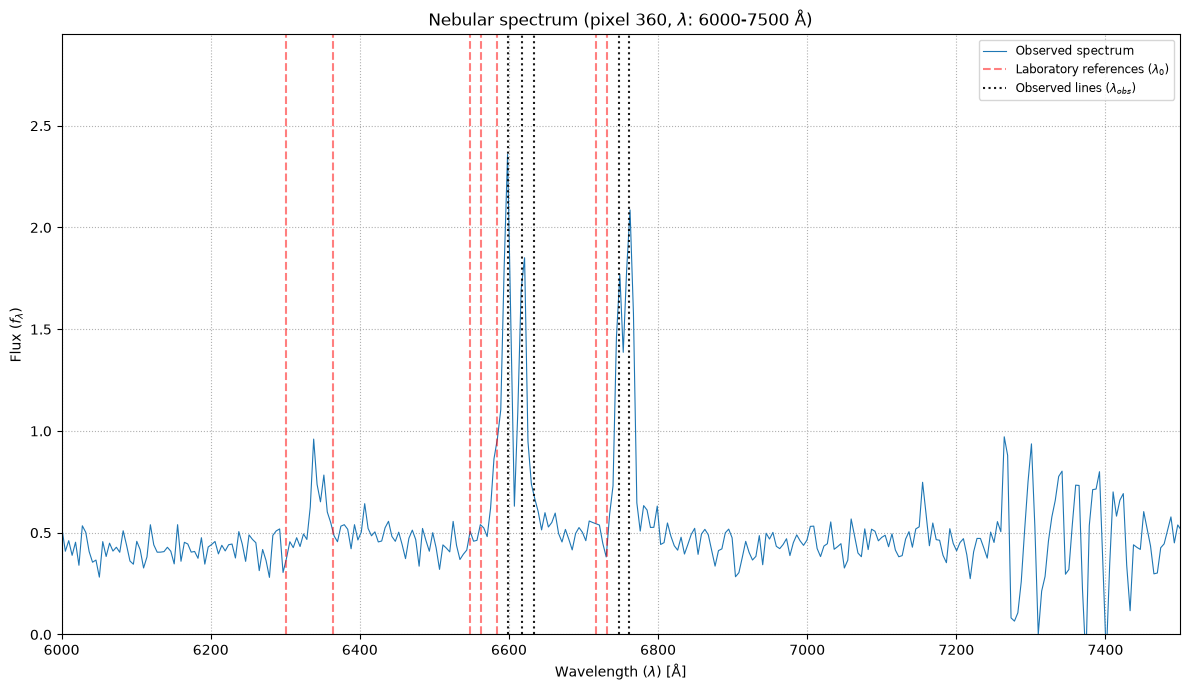


RADIAL-VELOCITY CALCULATION (Pixel 360)
Individual velocities [km/s]:
  O_III_2 : v = 1511.36 ± 302.27
  O_III   : v = 1496.87 ± 299.37
  N_II    : v = 2289.16 ± 228.92
  H_alpha : v = 2512.43 ± 228.40
  N_II_2  : v = 2276.88 ± 227.69
  S_II_1  : v = 1338.96 ± 223.16
  S_II_2  : v = 1336.17 ± 222.70

--------------------------------------------------
Number of lines used: 7
Weighted mean radial velocity:
V_radial = 1858.70 ± 91.33 km/s
--------------------------------------------------

Final result for pixel 360: V_radial = (1858.70 ± 91.33) km/s

Velocity data updated in the global list 'VELOCIDADES_POR_PIXEL'.


In [40]:
import os

try:
    PIXEL_CENTRAL = 360
except NameError:
    PIXEL_CENTRAL = 360

# Output directory for saved plots
RUTA_BASE_DESEADA = r"D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion"
os.makedirs(RUTA_BASE_DESEADA, exist_ok=True)
GRAFICOS_OUTPUT_DIR = RUTA_BASE_DESEADA

# Constants
C_LIGHT = 299792.458  # Speed of light in km/s

LINEAS_LAB = {
    'H_beta': 4861.32,
    'O_III_2': 4959.0,
    'O_III': 5007.0,
    'O_I_1': 6300.3,
    'O_I_2': 6363.8,
    'N_II': 6548.1,
    'H_alpha': 6562.8,
    'N_II_2': 6583.4,
    'S_II_1': 6717.0,
    'S_II_2': 6731.0
}

rango_graficas = [ (4500, 6000), (6000, 7500) ]
UMBRAL_PROMINENCE = 5

# Manually measured wavelength shifts for this spatial region
DESPLAZAMIENTOS = {
    'H_beta': 0,
    'O_III_2': 25,
    'O_III': 25,
    'O_I_1': 0,
    'O_I_2': 0,
    'N_II': 50,
    'N_II_2': 50,
    'H_alpha': 55,
    'S_II_1': 30,
    'S_II_2': 30,
}

# Adopted uncertainty in the observed wavelength [Å]
ERROR_LAMBDA_OBS = 5.0

velocidades_individuales = []

for nombre, lambda_0 in LINEAS_LAB.items():
    if nombre in DESPLAZAMIENTOS:
        desplazamiento = DESPLAZAMIENTOS[nombre]

        if desplazamiento != 0:
            v = C_LIGHT * (desplazamiento / lambda_0)
            delta_v = C_LIGHT * (ERROR_LAMBDA_OBS / lambda_0)

            velocidades_individuales.append({
                'Elemento': nombre,
                'v': v,
                'Delta_v': delta_v
            })

for idx_graph, (rango_min, rango_max) in enumerate(rango_graficas):

    plt.figure(figsize=(12, 7))

    etiqueta_ref_usada = False
    ETIQUETA_UNICA_REF = r'Laboratory references ($\lambda_0$)'
    etiqueta_obs_usada = False
    ETIQUETA_UNICA_OBS = r'Observed lines ($\lambda_{obs}$)'

    try:
        idx_rango = np.where((wavelength_array >= rango_min) & (wavelength_array <= rango_max))

        if len(idx_rango[0]) == 0:
            plt.close()
            print(f"Warning: No data in the {rango_min}-{rango_max} Å range. Skipping plot.")
            continue

        max_y_rango = neb_spec_360[idx_rango]
        max_y_rango = np.max(max_y_rango)
        plt.plot(wavelength_array, neb_spec_360, label='Observed spectrum', linewidth=0.8)

    except NameError:
        print("ERROR: Required data variables are not defined. Stopping the plotting loop.")
        break

    for nombre, lambda_0 in LINEAS_LAB.items():
        if lambda_0 < rango_min or lambda_0 > rango_max:
            continue

        label_ref = ETIQUETA_UNICA_REF if not etiqueta_ref_usada else None
        plt.axvline(x=lambda_0, color='r', linestyle='--', alpha=0.5, label=label_ref)
        etiqueta_ref_usada = True

    for nombre, lambda_0 in LINEAS_LAB.items():
        if rango_min <= lambda_0 < rango_max and nombre in DESPLAZAMIENTOS:
            desplazamiento = DESPLAZAMIENTOS[nombre]

            if desplazamiento != 0:
                lambda_obs = lambda_0 + desplazamiento
                label_obs = ETIQUETA_UNICA_OBS if not etiqueta_obs_usada else None
                plt.axvline(x=lambda_obs, color='k', linestyle=':', linewidth=1.5,
                            alpha=0.9, label=label_obs)
                etiqueta_obs_usada = True

    plt.xlim([rango_min, rango_max])
    plt.ylim([0, max_y_rango * 1.25])
    titulo_plot = fr"Nebular spectrum (pixel {PIXEL_CENTRAL}, $\lambda$: {rango_min}-{rango_max} Å)"
    plt.title(titulo_plot)
    plt.xlabel(r"Wavelength ($\lambda$) [Å]")
    plt.ylabel(r"Flux ($f_{\lambda}$)")
    plt.grid(True, linestyle=':')
    plt.legend(loc='upper right', fontsize='small')
    plt.tight_layout(rect=[0, 0, 1, 1])

    nombre_archivo = f"spectrum_pixel_{PIXEL_CENTRAL}_{rango_min}-{rango_max}.png"
    ruta_guardado_png = os.path.join(GRAFICOS_OUTPUT_DIR, nombre_archivo)
    plt.savefig(ruta_guardado_png, dpi=300)
    print(f"Plot saved: {ruta_guardado_png}")
    plt.show()
    plt.close()

print("\n" + "="*70)
print(f"RADIAL-VELOCITY CALCULATION (Pixel {PIXEL_CENTRAL})")
print("="*70)

if not velocidades_individuales:
    print("Warning: No shifted lines were found for the radial-velocity calculation.")
else:
    v_array = np.array([item['v'] for item in velocidades_individuales])
    dv_array = np.array([item['Delta_v'] for item in velocidades_individuales])

    weights = 1 / dv_array**2
    v_media_ponderada = np.sum(v_array * weights) / np.sum(weights)
    delta_v_media = np.sqrt(1 / np.sum(weights))

    nueva_entrada = {
        'Pixel_Central': PIXEL_CENTRAL,
        'V_Media': v_media_ponderada,
        'Delta_V_Media': delta_v_media,
        'V_Lineas': {item['Elemento']: {'v': item['v'], 'Delta_v': item['Delta_v']}
                     for item in velocidades_individuales}
    }

    indices_a_eliminar = []
    for i, entrada in enumerate(VELOCIDADES_POR_PIXEL):
        if entrada['Pixel_Central'] == PIXEL_CENTRAL:
            indices_a_eliminar.append(i)

    for i in sorted(indices_a_eliminar, reverse=True):
        del VELOCIDADES_POR_PIXEL[i]

    VELOCIDADES_POR_PIXEL.append(nueva_entrada)

    print("Individual velocities [km/s]:")
    for item in velocidades_individuales:
        print(f"  {item['Elemento']:<8}: v = {item['v']:.2f} ± {item['Delta_v']:.2f}")

    print("\n" + "-"*50)
    print(f"Number of lines used: {len(v_array)}")
    print("Weighted mean radial velocity:")
    print(f"V_radial = {v_media_ponderada:.2f} ± {delta_v_media:.2f} km/s")
    print("-"*50)

    print(f"\nFinal result for pixel {PIXEL_CENTRAL}: V_radial = "
          f"({v_media_ponderada:.2f} ± {delta_v_media:.2f}) km/s")

    print("\nVelocity data updated in the global list 'VELOCIDADES_POR_PIXEL'.")


### Region 2


In [41]:
neb_spec_400 = neb_spec_red[:,400:406]
sky_spec_6 = neb_spec_red[:,1000:1006]
sky_spec_6 = np.sum(sky_spec_6, axis=1)
neb_spec_400 = np.sum(neb_spec_400,axis=1)
neb_spec_400 = neb_spec_400 - sky_spec_6


Plot saved: D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion\spectrum_pixel_400_4500-6000.png


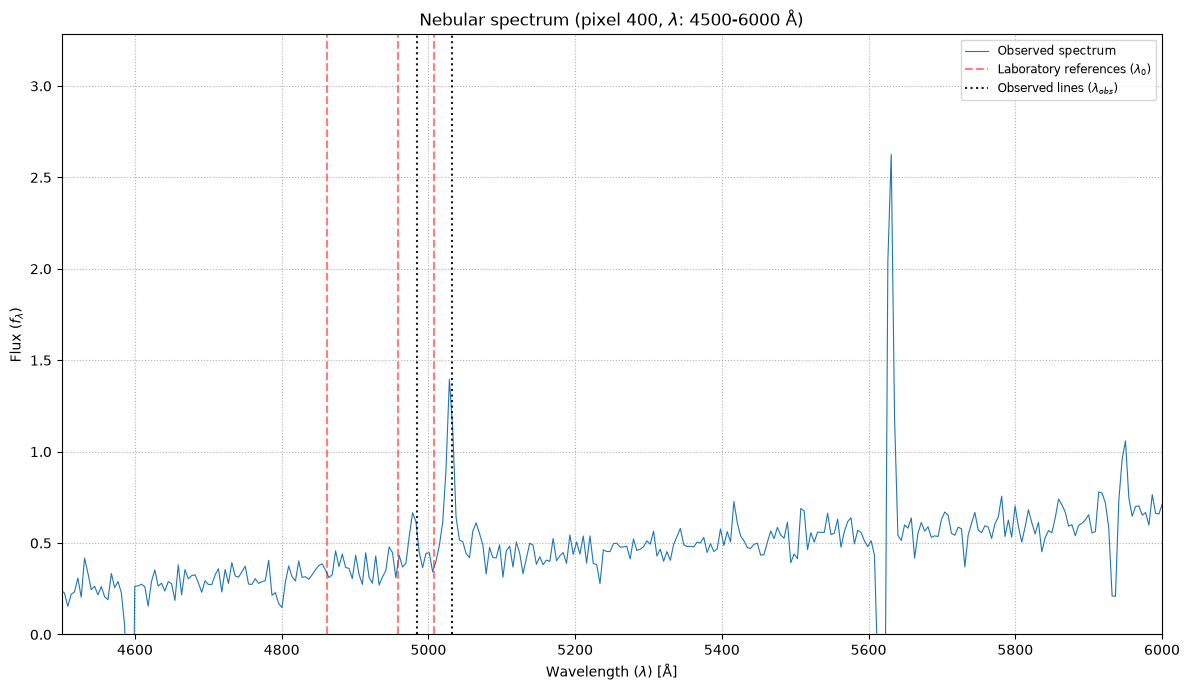

Plot saved: D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion\spectrum_pixel_400_6000-7500.png


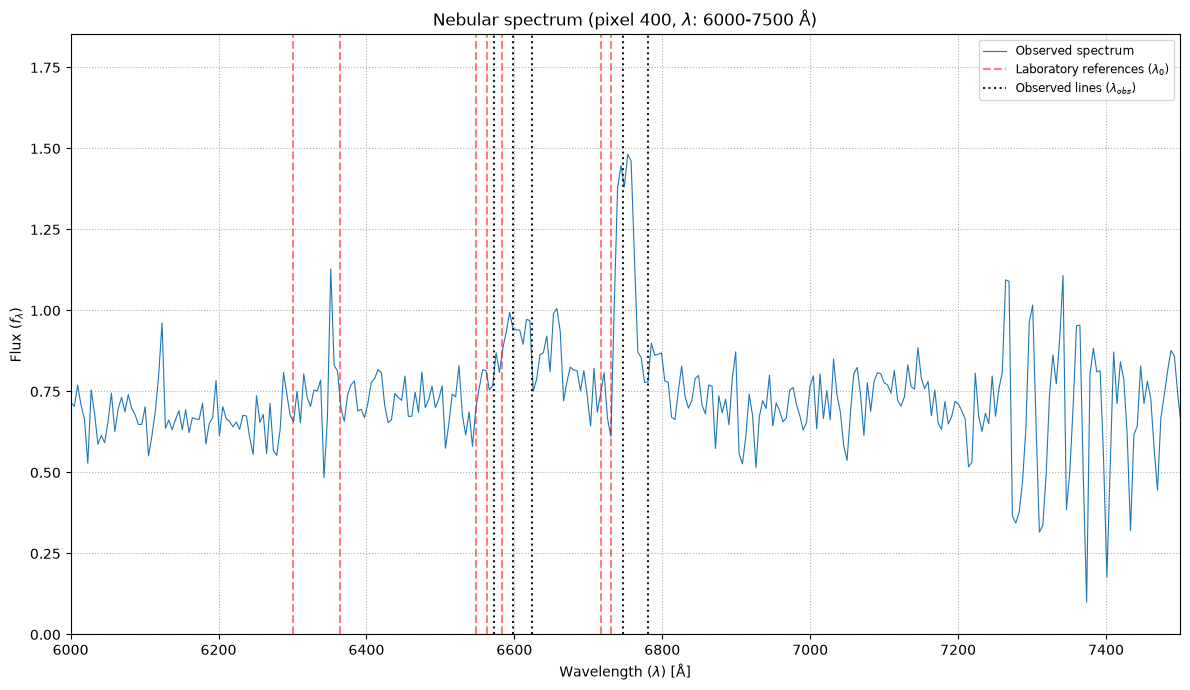


RADIAL-VELOCITY CALCULATION (Pixel 400)
Individual velocities [km/s]:
  O_III_2 : v = 1511.36 ± 302.27
  O_III   : v = 1496.87 ± 299.37
  N_II    : v = 1144.58 ± 228.92
  H_alpha : v = 1598.82 ± 228.40
  N_II_2  : v = 1821.51 ± 227.69
  S_II_1  : v = 1338.96 ± 223.16
  S_II_2  : v = 2226.95 ± 222.70

--------------------------------------------------
Number of lines used: 7
Weighted mean radial velocity:
V_radial = 1606.99 ± 91.33 km/s
--------------------------------------------------

Final result for pixel 400: V_radial = (1606.99 ± 91.33) km/s

Velocity data updated in the global list 'VELOCIDADES_POR_PIXEL'.


In [42]:
import os

try:
    PIXEL_CENTRAL = 400
except NameError:
    PIXEL_CENTRAL = 400

# Output directory for saved plots
RUTA_BASE_DESEADA = r"D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion"
os.makedirs(RUTA_BASE_DESEADA, exist_ok=True)
GRAFICOS_OUTPUT_DIR = RUTA_BASE_DESEADA

# Constants
C_LIGHT = 299792.458  # Speed of light in km/s

LINEAS_LAB = {
    'H_beta': 4861.32,
    'O_III_2': 4959.0,
    'O_III': 5007.0,
    'O_I_1': 6300.3,
    'O_I_2': 6363.8,
    'N_II': 6548.1,
    'H_alpha': 6562.8,
    'N_II_2': 6583.4,
    'S_II_1': 6717.0,
    'S_II_2': 6731.0
}

rango_graficas = [ (4500, 6000), (6000, 7500) ]
UMBRAL_PROMINENCE = 5

# Manually measured wavelength shifts for this spatial region
DESPLAZAMIENTOS = {
    'H_beta': 0,
    'O_III_2': 25,
    'O_III': 25,
    'O_I_1': 0,
    'O_I_2': 0,
    'N_II': 25,
    'N_II_2': 40,
    'H_alpha': 35,
    'S_II_1': 30,
    'S_II_2': 50,
}

# Adopted uncertainty in the observed wavelength [Å]
ERROR_LAMBDA_OBS = 5.0

velocidades_individuales = []

for nombre, lambda_0 in LINEAS_LAB.items():
    if nombre in DESPLAZAMIENTOS:
        desplazamiento = DESPLAZAMIENTOS[nombre]

        if desplazamiento != 0:
            v = C_LIGHT * (desplazamiento / lambda_0)
            delta_v = C_LIGHT * (ERROR_LAMBDA_OBS / lambda_0)

            velocidades_individuales.append({
                'Elemento': nombre,
                'v': v,
                'Delta_v': delta_v
            })

for idx_graph, (rango_min, rango_max) in enumerate(rango_graficas):

    plt.figure(figsize=(12, 7))

    etiqueta_ref_usada = False
    ETIQUETA_UNICA_REF = r'Laboratory references ($\lambda_0$)'
    etiqueta_obs_usada = False
    ETIQUETA_UNICA_OBS = r'Observed lines ($\lambda_{obs}$)'

    try:
        idx_rango = np.where((wavelength_array >= rango_min) & (wavelength_array <= rango_max))

        if len(idx_rango[0]) == 0:
            plt.close()
            print(f"Warning: No data in the {rango_min}-{rango_max} Å range. Skipping plot.")
            continue

        max_y_rango = neb_spec_400[idx_rango]
        max_y_rango = np.max(max_y_rango)
        plt.plot(wavelength_array, neb_spec_400, label='Observed spectrum', linewidth=0.8)

    except NameError:
        print("ERROR: Required data variables are not defined. Stopping the plotting loop.")
        break

    for nombre, lambda_0 in LINEAS_LAB.items():
        if lambda_0 < rango_min or lambda_0 > rango_max:
            continue

        label_ref = ETIQUETA_UNICA_REF if not etiqueta_ref_usada else None
        plt.axvline(x=lambda_0, color='r', linestyle='--', alpha=0.5, label=label_ref)
        etiqueta_ref_usada = True

    for nombre, lambda_0 in LINEAS_LAB.items():
        if rango_min <= lambda_0 < rango_max and nombre in DESPLAZAMIENTOS:
            desplazamiento = DESPLAZAMIENTOS[nombre]

            if desplazamiento != 0:
                lambda_obs = lambda_0 + desplazamiento
                label_obs = ETIQUETA_UNICA_OBS if not etiqueta_obs_usada else None
                plt.axvline(x=lambda_obs, color='k', linestyle=':', linewidth=1.5,
                            alpha=0.9, label=label_obs)
                etiqueta_obs_usada = True

    plt.xlim([rango_min, rango_max])
    plt.ylim([0, max_y_rango * 1.25])
    titulo_plot = fr"Nebular spectrum (pixel {PIXEL_CENTRAL}, $\lambda$: {rango_min}-{rango_max} Å)"
    plt.title(titulo_plot)
    plt.xlabel(r"Wavelength ($\lambda$) [Å]")
    plt.ylabel(r"Flux ($f_{\lambda}$)")
    plt.grid(True, linestyle=':')
    plt.legend(loc='upper right', fontsize='small')
    plt.tight_layout(rect=[0, 0, 1, 1])

    nombre_archivo = f"spectrum_pixel_{PIXEL_CENTRAL}_{rango_min}-{rango_max}.png"
    ruta_guardado_png = os.path.join(GRAFICOS_OUTPUT_DIR, nombre_archivo)
    plt.savefig(ruta_guardado_png, dpi=300)
    print(f"Plot saved: {ruta_guardado_png}")
    plt.show()
    plt.close()

print("\n" + "="*70)
print(f"RADIAL-VELOCITY CALCULATION (Pixel {PIXEL_CENTRAL})")
print("="*70)

if not velocidades_individuales:
    print("Warning: No shifted lines were found for the radial-velocity calculation.")
else:
    v_array = np.array([item['v'] for item in velocidades_individuales])
    dv_array = np.array([item['Delta_v'] for item in velocidades_individuales])

    weights = 1 / dv_array**2
    v_media_ponderada = np.sum(v_array * weights) / np.sum(weights)
    delta_v_media = np.sqrt(1 / np.sum(weights))

    nueva_entrada = {
        'Pixel_Central': PIXEL_CENTRAL,
        'V_Media': v_media_ponderada,
        'Delta_V_Media': delta_v_media,
        'V_Lineas': {item['Elemento']: {'v': item['v'], 'Delta_v': item['Delta_v']}
                     for item in velocidades_individuales}
    }

    indices_a_eliminar = []
    for i, entrada in enumerate(VELOCIDADES_POR_PIXEL):
        if entrada['Pixel_Central'] == PIXEL_CENTRAL:
            indices_a_eliminar.append(i)

    for i in sorted(indices_a_eliminar, reverse=True):
        del VELOCIDADES_POR_PIXEL[i]

    VELOCIDADES_POR_PIXEL.append(nueva_entrada)

    print("Individual velocities [km/s]:")
    for item in velocidades_individuales:
        print(f"  {item['Elemento']:<8}: v = {item['v']:.2f} ± {item['Delta_v']:.2f}")

    print("\n" + "-"*50)
    print(f"Number of lines used: {len(v_array)}")
    print("Weighted mean radial velocity:")
    print(f"V_radial = {v_media_ponderada:.2f} ± {delta_v_media:.2f} km/s")
    print("-"*50)

    print(f"\nFinal result for pixel {PIXEL_CENTRAL}: V_radial = "
          f"({v_media_ponderada:.2f} ± {delta_v_media:.2f}) km/s")

    print("\nVelocity data updated in the global list 'VELOCIDADES_POR_PIXEL'.")


### Region 3


In [43]:
neb_spec_425 = neb_spec_red[:,425:431]
sky_spec_6 = neb_spec_red[:,1000:1006]
sky_spec_6 = np.sum(sky_spec_6, axis=1)
neb_spec_425 = np.sum(neb_spec_425,axis=1)
neb_spec_425 = neb_spec_425 - sky_spec_6


Plot saved: D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion\spectrum_pixel_425_4500-6000.png


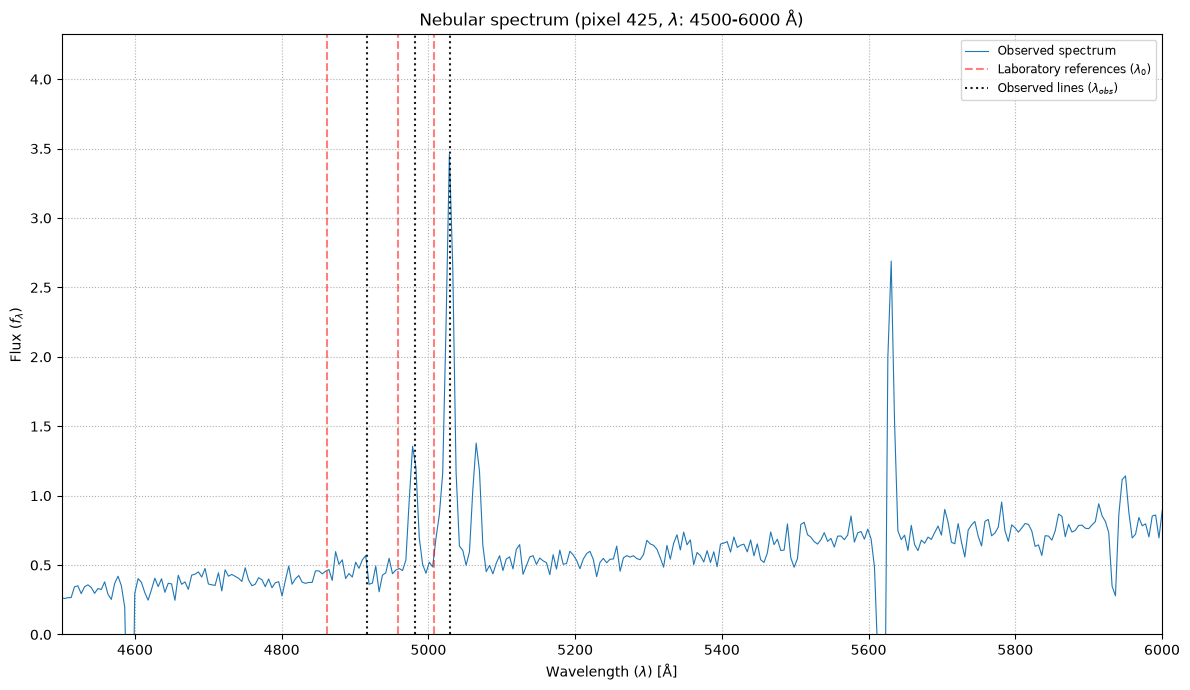

Plot saved: D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion\spectrum_pixel_425_6000-7500.png


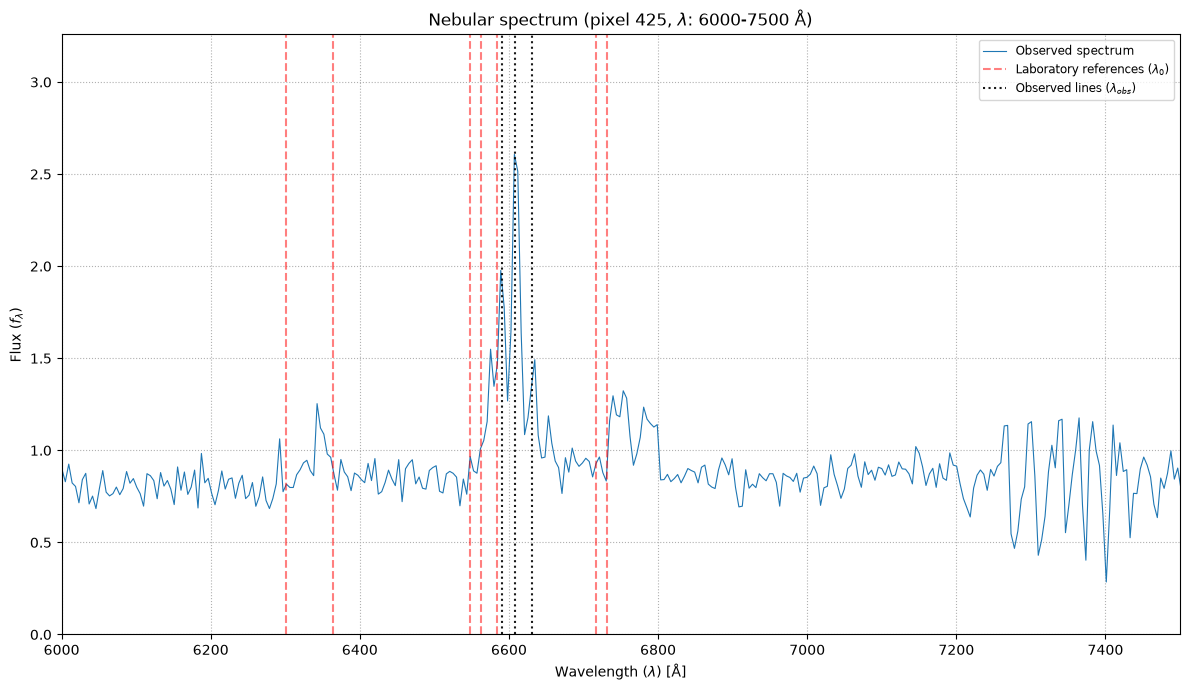


RADIAL-VELOCITY CALCULATION (Pixel 425)
Individual velocities [km/s]:
  H_beta  : v = 3391.79 ± 308.34
  O_III_2 : v = 1390.45 ± 302.27
  O_III   : v = 1377.12 ± 299.37
  N_II    : v = 1968.67 ± 228.92
  H_alpha : v = 2055.63 ± 228.40
  N_II_2  : v = 2185.81 ± 227.69

--------------------------------------------------
Number of lines used: 6
Weighted mean radial velocity:
V_radial = 2056.23 ± 105.31 km/s
--------------------------------------------------

Final result for pixel 425: V_radial = (2056.23 ± 105.31) km/s

Velocity data updated in the global list 'VELOCIDADES_POR_PIXEL'.


In [44]:
import os

try:
    PIXEL_CENTRAL = 425
except NameError:
    PIXEL_CENTRAL = 425

# Output directory for saved plots
RUTA_BASE_DESEADA = r"D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion"
os.makedirs(RUTA_BASE_DESEADA, exist_ok=True)
GRAFICOS_OUTPUT_DIR = RUTA_BASE_DESEADA

# Constants
C_LIGHT = 299792.458  # Speed of light in km/s

LINEAS_LAB = {
    'H_beta': 4861.32,
    'O_III_2': 4959.0,
    'O_III': 5007.0,
    'O_I_1': 6300.3,
    'O_I_2': 6363.8,
    'N_II': 6548.1,
    'H_alpha': 6562.8,
    'N_II_2': 6583.4,
    'S_II_1': 6717.0,
    'S_II_2': 6731.0
}

rango_graficas = [ (4500, 6000), (6000, 7500) ]
UMBRAL_PROMINENCE = 5

# Manually measured wavelength shifts for this spatial region
DESPLAZAMIENTOS = {
    'H_beta': 55,
    'O_III_2': 23,
    'O_III': 23,
    'O_I_1': 0,
    'O_I_2': 0,
    'N_II': 43,
    'N_II_2': 48,
    'H_alpha': 45,
    'S_II_1': 0,
    'S_II_2': 0,
}

# Adopted uncertainty in the observed wavelength [Å]
ERROR_LAMBDA_OBS = 5.0

velocidades_individuales = []

for nombre, lambda_0 in LINEAS_LAB.items():
    if nombre in DESPLAZAMIENTOS:
        desplazamiento = DESPLAZAMIENTOS[nombre]

        if desplazamiento != 0:
            v = C_LIGHT * (desplazamiento / lambda_0)
            delta_v = C_LIGHT * (ERROR_LAMBDA_OBS / lambda_0)

            velocidades_individuales.append({
                'Elemento': nombre,
                'v': v,
                'Delta_v': delta_v
            })

for idx_graph, (rango_min, rango_max) in enumerate(rango_graficas):

    plt.figure(figsize=(12, 7))

    etiqueta_ref_usada = False
    ETIQUETA_UNICA_REF = r'Laboratory references ($\lambda_0$)'
    etiqueta_obs_usada = False
    ETIQUETA_UNICA_OBS = r'Observed lines ($\lambda_{obs}$)'

    try:
        idx_rango = np.where((wavelength_array >= rango_min) & (wavelength_array <= rango_max))

        if len(idx_rango[0]) == 0:
            plt.close()
            print(f"Warning: No data in the {rango_min}-{rango_max} Å range. Skipping plot.")
            continue

        max_y_rango = neb_spec_425[idx_rango]
        max_y_rango = np.max(max_y_rango)
        plt.plot(wavelength_array, neb_spec_425, label='Observed spectrum', linewidth=0.8)

    except NameError:
        print("ERROR: Required data variables are not defined. Stopping the plotting loop.")
        break

    for nombre, lambda_0 in LINEAS_LAB.items():
        if lambda_0 < rango_min or lambda_0 > rango_max:
            continue

        label_ref = ETIQUETA_UNICA_REF if not etiqueta_ref_usada else None
        plt.axvline(x=lambda_0, color='r', linestyle='--', alpha=0.5, label=label_ref)
        etiqueta_ref_usada = True

    for nombre, lambda_0 in LINEAS_LAB.items():
        if rango_min <= lambda_0 < rango_max and nombre in DESPLAZAMIENTOS:
            desplazamiento = DESPLAZAMIENTOS[nombre]

            if desplazamiento != 0:
                lambda_obs = lambda_0 + desplazamiento
                label_obs = ETIQUETA_UNICA_OBS if not etiqueta_obs_usada else None
                plt.axvline(x=lambda_obs, color='k', linestyle=':', linewidth=1.5,
                            alpha=0.9, label=label_obs)
                etiqueta_obs_usada = True

    plt.xlim([rango_min, rango_max])
    plt.ylim([0, max_y_rango * 1.25])
    titulo_plot = fr"Nebular spectrum (pixel {PIXEL_CENTRAL}, $\lambda$: {rango_min}-{rango_max} Å)"
    plt.title(titulo_plot)
    plt.xlabel(r"Wavelength ($\lambda$) [Å]")
    plt.ylabel(r"Flux ($f_{\lambda}$)")
    plt.grid(True, linestyle=':')
    plt.legend(loc='upper right', fontsize='small')
    plt.tight_layout(rect=[0, 0, 1, 1])

    nombre_archivo = f"spectrum_pixel_{PIXEL_CENTRAL}_{rango_min}-{rango_max}.png"
    ruta_guardado_png = os.path.join(GRAFICOS_OUTPUT_DIR, nombre_archivo)
    plt.savefig(ruta_guardado_png, dpi=300)
    print(f"Plot saved: {ruta_guardado_png}")
    plt.show()
    plt.close()

print("\n" + "="*70)
print(f"RADIAL-VELOCITY CALCULATION (Pixel {PIXEL_CENTRAL})")
print("="*70)

if not velocidades_individuales:
    print("Warning: No shifted lines were found for the radial-velocity calculation.")
else:
    v_array = np.array([item['v'] for item in velocidades_individuales])
    dv_array = np.array([item['Delta_v'] for item in velocidades_individuales])

    weights = 1 / dv_array**2
    v_media_ponderada = np.sum(v_array * weights) / np.sum(weights)
    delta_v_media = np.sqrt(1 / np.sum(weights))

    nueva_entrada = {
        'Pixel_Central': PIXEL_CENTRAL,
        'V_Media': v_media_ponderada,
        'Delta_V_Media': delta_v_media,
        'V_Lineas': {item['Elemento']: {'v': item['v'], 'Delta_v': item['Delta_v']}
                     for item in velocidades_individuales}
    }

    indices_a_eliminar = []
    for i, entrada in enumerate(VELOCIDADES_POR_PIXEL):
        if entrada['Pixel_Central'] == PIXEL_CENTRAL:
            indices_a_eliminar.append(i)

    for i in sorted(indices_a_eliminar, reverse=True):
        del VELOCIDADES_POR_PIXEL[i]

    VELOCIDADES_POR_PIXEL.append(nueva_entrada)

    print("Individual velocities [km/s]:")
    for item in velocidades_individuales:
        print(f"  {item['Elemento']:<8}: v = {item['v']:.2f} ± {item['Delta_v']:.2f}")

    print("\n" + "-"*50)
    print(f"Number of lines used: {len(v_array)}")
    print("Weighted mean radial velocity:")
    print(f"V_radial = {v_media_ponderada:.2f} ± {delta_v_media:.2f} km/s")
    print("-"*50)

    print(f"\nFinal result for pixel {PIXEL_CENTRAL}: V_radial = "
          f"({v_media_ponderada:.2f} ± {delta_v_media:.2f}) km/s")

    print("\nVelocity data updated in the global list 'VELOCIDADES_POR_PIXEL'.")


### Region 4


In [45]:
neb_spec_466 = neb_spec_red[:,466:472]
sky_spec_6 = neb_spec_red[:,1000:1006]
sky_spec_6 = np.sum(sky_spec_6, axis=1)
neb_spec_466 = np.sum(neb_spec_466,axis=1)
neb_spec_466 = neb_spec_466 - sky_spec_6


Plot saved: D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion\spectrum_pixel_466_4500-6000.png


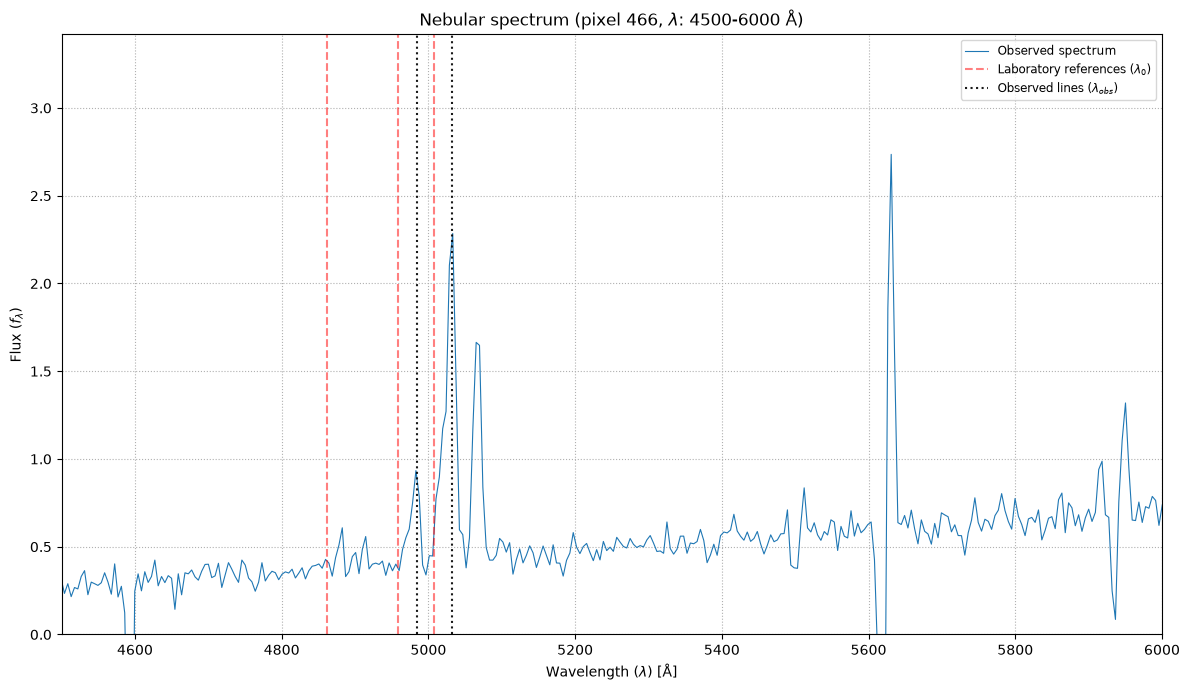

Plot saved: D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion\spectrum_pixel_466_6000-7500.png


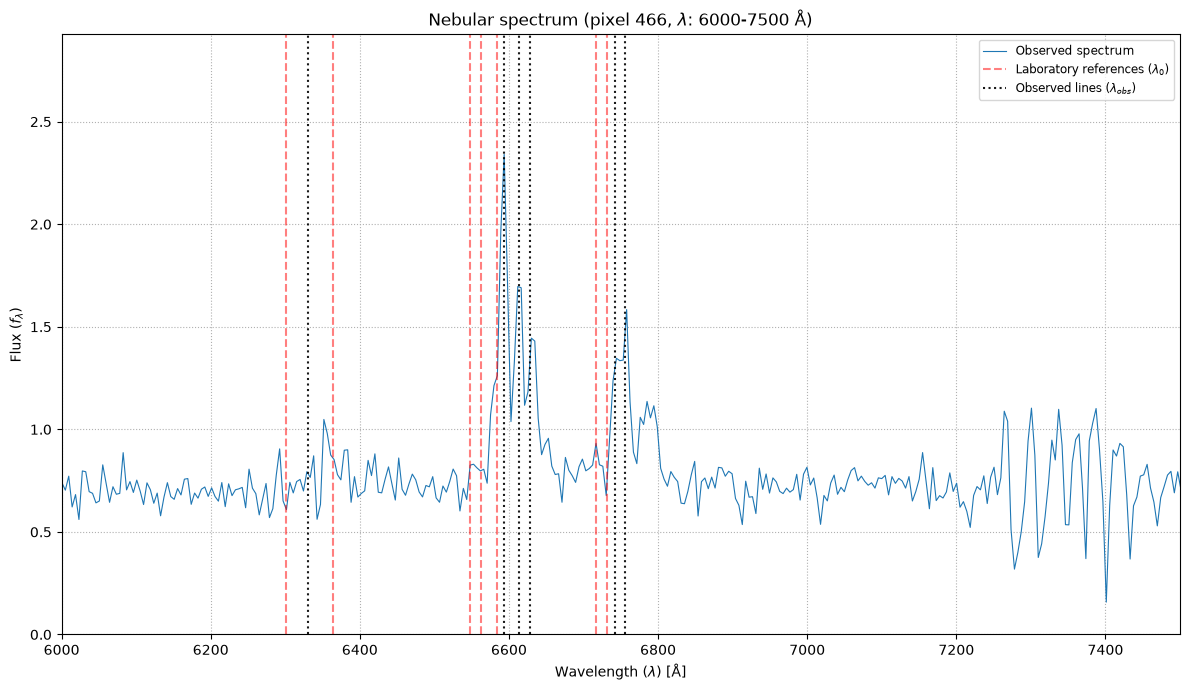


RADIAL-VELOCITY CALCULATION (Pixel 466)
Individual velocities [km/s]:
  O_III_2 : v = 1511.36 ± 302.27
  O_III   : v = 1496.87 ± 299.37
  O_I_1   : v = 1427.52 ± 237.92
  N_II    : v = 2060.24 ± 228.92
  H_alpha : v = 2284.03 ± 228.40
  N_II_2  : v = 2049.19 ± 227.69
  S_II_1  : v = 1115.80 ± 223.16
  S_II_2  : v = 1113.48 ± 222.70

--------------------------------------------------
Number of lines used: 8
Weighted mean radial velocity:
V_radial = 1642.59 ± 85.26 km/s
--------------------------------------------------

Final result for pixel 466: V_radial = (1642.59 ± 85.26) km/s

Velocity data updated in the global list 'VELOCIDADES_POR_PIXEL'.


In [46]:
import os

try:
    PIXEL_CENTRAL = 466
except NameError:
    PIXEL_CENTRAL = 466

# Output directory for saved plots
RUTA_BASE_DESEADA = r"D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion"
os.makedirs(RUTA_BASE_DESEADA, exist_ok=True)
GRAFICOS_OUTPUT_DIR = RUTA_BASE_DESEADA

# Constants
C_LIGHT = 299792.458  # Speed of light in km/s

LINEAS_LAB = {
    'H_beta': 4861.32,
    'O_III_2': 4959.0,
    'O_III': 5007.0,
    'O_I_1': 6300.3,
    'O_I_2': 6363.8,
    'N_II': 6548.1,
    'H_alpha': 6562.8,
    'N_II_2': 6583.4,
    'S_II_1': 6717.0,
    'S_II_2': 6731.0
}

rango_graficas = [ (4500, 6000), (6000, 7500) ]
UMBRAL_PROMINENCE = 5

# Manually measured wavelength shifts for this spatial region
DESPLAZAMIENTOS = {
    'H_beta': 0,
    'O_III_2': 25,
    'O_III': 25,
    'O_I_1': 30,
    'O_I_2': 0,
    'N_II': 45,
    'N_II_2': 45,
    'H_alpha': 50,
    'S_II_1': 25,
    'S_II_2': 25,
}

# Adopted uncertainty in the observed wavelength [Å]
ERROR_LAMBDA_OBS = 5.0

velocidades_individuales = []

for nombre, lambda_0 in LINEAS_LAB.items():
    if nombre in DESPLAZAMIENTOS:
        desplazamiento = DESPLAZAMIENTOS[nombre]

        if desplazamiento != 0:
            v = C_LIGHT * (desplazamiento / lambda_0)
            delta_v = C_LIGHT * (ERROR_LAMBDA_OBS / lambda_0)

            velocidades_individuales.append({
                'Elemento': nombre,
                'v': v,
                'Delta_v': delta_v
            })

for idx_graph, (rango_min, rango_max) in enumerate(rango_graficas):

    plt.figure(figsize=(12, 7))

    etiqueta_ref_usada = False
    ETIQUETA_UNICA_REF = r'Laboratory references ($\lambda_0$)'
    etiqueta_obs_usada = False
    ETIQUETA_UNICA_OBS = r'Observed lines ($\lambda_{obs}$)'

    try:
        idx_rango = np.where((wavelength_array >= rango_min) & (wavelength_array <= rango_max))

        if len(idx_rango[0]) == 0:
            plt.close()
            print(f"Warning: No data in the {rango_min}-{rango_max} Å range. Skipping plot.")
            continue

        max_y_rango = neb_spec_466[idx_rango]
        max_y_rango = np.max(max_y_rango)
        plt.plot(wavelength_array, neb_spec_466, label='Observed spectrum', linewidth=0.8)

    except NameError:
        print("ERROR: Required data variables are not defined. Stopping the plotting loop.")
        break

    for nombre, lambda_0 in LINEAS_LAB.items():
        if lambda_0 < rango_min or lambda_0 > rango_max:
            continue

        label_ref = ETIQUETA_UNICA_REF if not etiqueta_ref_usada else None
        plt.axvline(x=lambda_0, color='r', linestyle='--', alpha=0.5, label=label_ref)
        etiqueta_ref_usada = True

    for nombre, lambda_0 in LINEAS_LAB.items():
        if rango_min <= lambda_0 < rango_max and nombre in DESPLAZAMIENTOS:
            desplazamiento = DESPLAZAMIENTOS[nombre]

            if desplazamiento != 0:
                lambda_obs = lambda_0 + desplazamiento
                label_obs = ETIQUETA_UNICA_OBS if not etiqueta_obs_usada else None
                plt.axvline(x=lambda_obs, color='k', linestyle=':', linewidth=1.5,
                            alpha=0.9, label=label_obs)
                etiqueta_obs_usada = True

    plt.xlim([rango_min, rango_max])
    plt.ylim([0, max_y_rango * 1.25])
    titulo_plot = fr"Nebular spectrum (pixel {PIXEL_CENTRAL}, $\lambda$: {rango_min}-{rango_max} Å)"
    plt.title(titulo_plot)
    plt.xlabel(r"Wavelength ($\lambda$) [Å]")
    plt.ylabel(r"Flux ($f_{\lambda}$)")
    plt.grid(True, linestyle=':')
    plt.legend(loc='upper right', fontsize='small')
    plt.tight_layout(rect=[0, 0, 1, 1])

    nombre_archivo = f"spectrum_pixel_{PIXEL_CENTRAL}_{rango_min}-{rango_max}.png"
    ruta_guardado_png = os.path.join(GRAFICOS_OUTPUT_DIR, nombre_archivo)
    plt.savefig(ruta_guardado_png, dpi=300)
    print(f"Plot saved: {ruta_guardado_png}")
    plt.show()
    plt.close()

print("\n" + "="*70)
print(f"RADIAL-VELOCITY CALCULATION (Pixel {PIXEL_CENTRAL})")
print("="*70)

if not velocidades_individuales:
    print("Warning: No shifted lines were found for the radial-velocity calculation.")
else:
    v_array = np.array([item['v'] for item in velocidades_individuales])
    dv_array = np.array([item['Delta_v'] for item in velocidades_individuales])

    weights = 1 / dv_array**2
    v_media_ponderada = np.sum(v_array * weights) / np.sum(weights)
    delta_v_media = np.sqrt(1 / np.sum(weights))

    nueva_entrada = {
        'Pixel_Central': PIXEL_CENTRAL,
        'V_Media': v_media_ponderada,
        'Delta_V_Media': delta_v_media,
        'V_Lineas': {item['Elemento']: {'v': item['v'], 'Delta_v': item['Delta_v']}
                     for item in velocidades_individuales}
    }

    indices_a_eliminar = []
    for i, entrada in enumerate(VELOCIDADES_POR_PIXEL):
        if entrada['Pixel_Central'] == PIXEL_CENTRAL:
            indices_a_eliminar.append(i)

    for i in sorted(indices_a_eliminar, reverse=True):
        del VELOCIDADES_POR_PIXEL[i]

    VELOCIDADES_POR_PIXEL.append(nueva_entrada)

    print("Individual velocities [km/s]:")
    for item in velocidades_individuales:
        print(f"  {item['Elemento']:<8}: v = {item['v']:.2f} ± {item['Delta_v']:.2f}")

    print("\n" + "-"*50)
    print(f"Number of lines used: {len(v_array)}")
    print("Weighted mean radial velocity:")
    print(f"V_radial = {v_media_ponderada:.2f} ± {delta_v_media:.2f} km/s")
    print("-"*50)

    print(f"\nFinal result for pixel {PIXEL_CENTRAL}: V_radial = "
          f"({v_media_ponderada:.2f} ± {delta_v_media:.2f}) km/s")

    print("\nVelocity data updated in the global list 'VELOCIDADES_POR_PIXEL'.")


### Region 5


In [47]:
neb_spec_510 = neb_spec_red[:,510:516]
sky_spec_6 = neb_spec_red[:,1000:1006]
sky_spec_6 = np.sum(sky_spec_6, axis=1)
neb_spec_510 = np.sum(neb_spec_510,axis=1)
neb_spec_510 = neb_spec_510 - sky_spec_6


Plot saved: D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion\spectrum_pixel_510_4500-6000.png


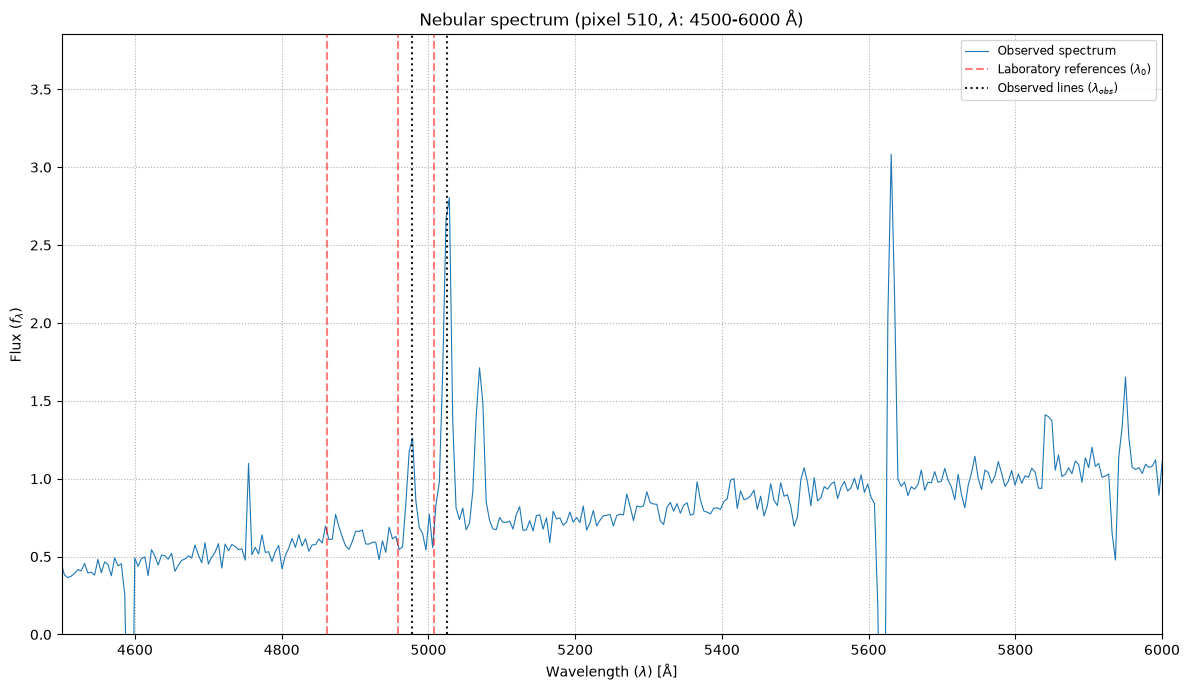

Plot saved: D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion\spectrum_pixel_510_6000-7500.png


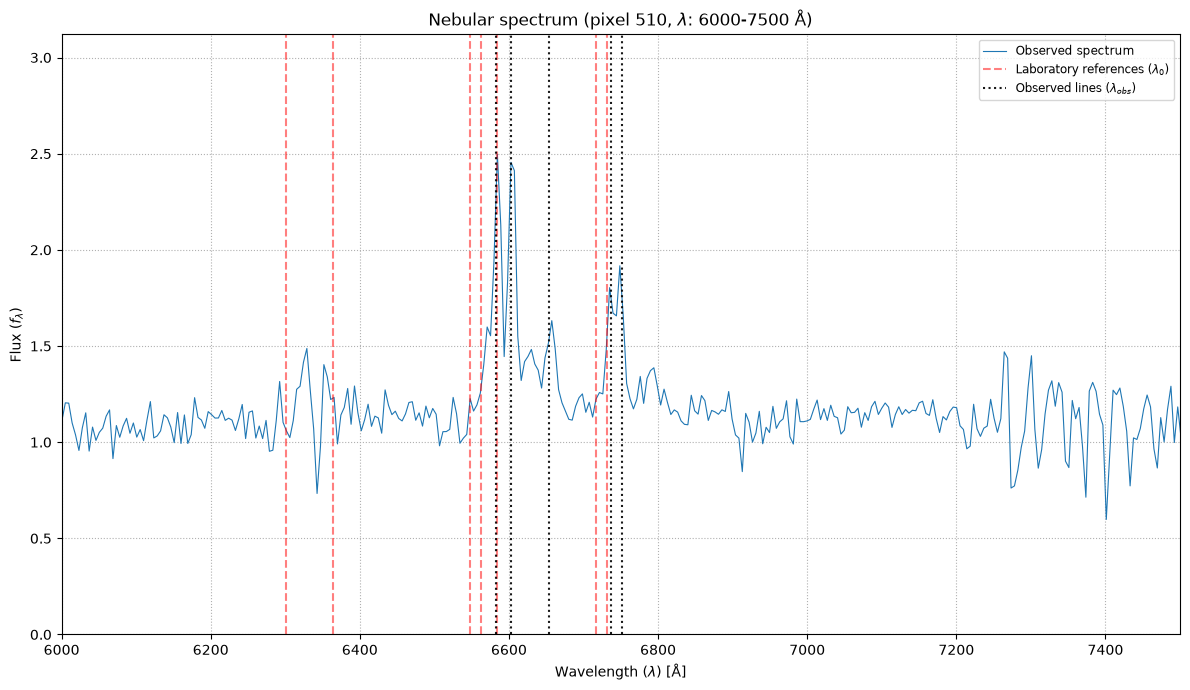


RADIAL-VELOCITY CALCULATION (Pixel 510)
Individual velocities [km/s]:
  O_III_2 : v = 1088.18 ± 302.27
  O_III   : v = 1077.74 ± 299.37
  N_II    : v = 1602.41 ± 228.92
  H_alpha : v = 1827.22 ± 228.40
  N_II_2  : v = 3187.63 ± 227.69
  S_II_1  : v = 892.64 ± 223.16
  S_II_2  : v = 890.78 ± 222.70

--------------------------------------------------
Number of lines used: 7
Weighted mean radial velocity:
V_radial = 1559.07 ± 91.33 km/s
--------------------------------------------------

Final result for pixel 510: V_radial = (1559.07 ± 91.33) km/s

Velocity data updated in the global list 'VELOCIDADES_POR_PIXEL'.


In [48]:
import os

try:
    PIXEL_CENTRAL = 510
except NameError:
    PIXEL_CENTRAL = 510

# Output directory for saved plots
RUTA_BASE_DESEADA = r"D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion"
os.makedirs(RUTA_BASE_DESEADA, exist_ok=True)
GRAFICOS_OUTPUT_DIR = RUTA_BASE_DESEADA

# Constants
C_LIGHT = 299792.458  # Speed of light in km/s

LINEAS_LAB = {
    'H_beta': 4861.32,
    'O_III_2': 4959.0,
    'O_III': 5007.0,
    'O_I_1': 6300.3,
    'O_I_2': 6363.8,
    'N_II': 6548.1,
    'H_alpha': 6562.8,
    'N_II_2': 6583.4,
    'S_II_1': 6717.0,
    'S_II_2': 6731.0
}

rango_graficas = [ (4500, 6000), (6000, 7500) ]
UMBRAL_PROMINENCE = 5

# Manually measured wavelength shifts for this spatial region
DESPLAZAMIENTOS = {
    'H_beta': 0,
    'O_III_2': 18,
    'O_III': 18,
    'O_I_1': 0,
    'O_I_2': 0,
    'N_II': 35,
    'N_II_2': 70,
    'H_alpha': 40,
    'S_II_1': 20,
    'S_II_2': 20,
}

# Adopted uncertainty in the observed wavelength [Å]
ERROR_LAMBDA_OBS = 5.0

velocidades_individuales = []

for nombre, lambda_0 in LINEAS_LAB.items():
    if nombre in DESPLAZAMIENTOS:
        desplazamiento = DESPLAZAMIENTOS[nombre]

        if desplazamiento != 0:
            v = C_LIGHT * (desplazamiento / lambda_0)
            delta_v = C_LIGHT * (ERROR_LAMBDA_OBS / lambda_0)

            velocidades_individuales.append({
                'Elemento': nombre,
                'v': v,
                'Delta_v': delta_v
            })

for idx_graph, (rango_min, rango_max) in enumerate(rango_graficas):

    plt.figure(figsize=(12, 7))

    etiqueta_ref_usada = False
    ETIQUETA_UNICA_REF = r'Laboratory references ($\lambda_0$)'
    etiqueta_obs_usada = False
    ETIQUETA_UNICA_OBS = r'Observed lines ($\lambda_{obs}$)'

    try:
        idx_rango = np.where((wavelength_array >= rango_min) & (wavelength_array <= rango_max))

        if len(idx_rango[0]) == 0:
            plt.close()
            print(f"Warning: No data in the {rango_min}-{rango_max} Å range. Skipping plot.")
            continue

        max_y_rango = neb_spec_510[idx_rango]
        max_y_rango = np.max(max_y_rango)
        plt.plot(wavelength_array, neb_spec_510, label='Observed spectrum', linewidth=0.8)

    except NameError:
        print("ERROR: Required data variables are not defined. Stopping the plotting loop.")
        break

    for nombre, lambda_0 in LINEAS_LAB.items():
        if lambda_0 < rango_min or lambda_0 > rango_max:
            continue

        label_ref = ETIQUETA_UNICA_REF if not etiqueta_ref_usada else None
        plt.axvline(x=lambda_0, color='r', linestyle='--', alpha=0.5, label=label_ref)
        etiqueta_ref_usada = True

    for nombre, lambda_0 in LINEAS_LAB.items():
        if rango_min <= lambda_0 < rango_max and nombre in DESPLAZAMIENTOS:
            desplazamiento = DESPLAZAMIENTOS[nombre]

            if desplazamiento != 0:
                lambda_obs = lambda_0 + desplazamiento
                label_obs = ETIQUETA_UNICA_OBS if not etiqueta_obs_usada else None
                plt.axvline(x=lambda_obs, color='k', linestyle=':', linewidth=1.5,
                            alpha=0.9, label=label_obs)
                etiqueta_obs_usada = True

    plt.xlim([rango_min, rango_max])
    plt.ylim([0, max_y_rango * 1.25])
    titulo_plot = fr"Nebular spectrum (pixel {PIXEL_CENTRAL}, $\lambda$: {rango_min}-{rango_max} Å)"
    plt.title(titulo_plot)
    plt.xlabel(r"Wavelength ($\lambda$) [Å]")
    plt.ylabel(r"Flux ($f_{\lambda}$)")
    plt.grid(True, linestyle=':')
    plt.legend(loc='upper right', fontsize='small')
    plt.tight_layout(rect=[0, 0, 1, 1])

    nombre_archivo = f"spectrum_pixel_{PIXEL_CENTRAL}_{rango_min}-{rango_max}.png"
    ruta_guardado_png = os.path.join(GRAFICOS_OUTPUT_DIR, nombre_archivo)
    plt.savefig(ruta_guardado_png, dpi=300)
    print(f"Plot saved: {ruta_guardado_png}")
    plt.show()
    plt.close()

print("\n" + "="*70)
print(f"RADIAL-VELOCITY CALCULATION (Pixel {PIXEL_CENTRAL})")
print("="*70)

if not velocidades_individuales:
    print("Warning: No shifted lines were found for the radial-velocity calculation.")
else:
    v_array = np.array([item['v'] for item in velocidades_individuales])
    dv_array = np.array([item['Delta_v'] for item in velocidades_individuales])

    weights = 1 / dv_array**2
    v_media_ponderada = np.sum(v_array * weights) / np.sum(weights)
    delta_v_media = np.sqrt(1 / np.sum(weights))

    nueva_entrada = {
        'Pixel_Central': PIXEL_CENTRAL,
        'V_Media': v_media_ponderada,
        'Delta_V_Media': delta_v_media,
        'V_Lineas': {item['Elemento']: {'v': item['v'], 'Delta_v': item['Delta_v']}
                     for item in velocidades_individuales}
    }

    indices_a_eliminar = []
    for i, entrada in enumerate(VELOCIDADES_POR_PIXEL):
        if entrada['Pixel_Central'] == PIXEL_CENTRAL:
            indices_a_eliminar.append(i)

    for i in sorted(indices_a_eliminar, reverse=True):
        del VELOCIDADES_POR_PIXEL[i]

    VELOCIDADES_POR_PIXEL.append(nueva_entrada)

    print("Individual velocities [km/s]:")
    for item in velocidades_individuales:
        print(f"  {item['Elemento']:<8}: v = {item['v']:.2f} ± {item['Delta_v']:.2f}")

    print("\n" + "-"*50)
    print(f"Number of lines used: {len(v_array)}")
    print("Weighted mean radial velocity:")
    print(f"V_radial = {v_media_ponderada:.2f} ± {delta_v_media:.2f} km/s")
    print("-"*50)

    print(f"\nFinal result for pixel {PIXEL_CENTRAL}: V_radial = "
          f"({v_media_ponderada:.2f} ± {delta_v_media:.2f}) km/s")

    print("\nVelocity data updated in the global list 'VELOCIDADES_POR_PIXEL'.")


### Region 6


In [49]:
neb_spec_536 = neb_spec_red[:,536:542]
sky_spec_6 = neb_spec_red[:,1000:1006]
sky_spec_6 = np.sum(sky_spec_6, axis=1)
neb_spec_536 = np.sum(neb_spec_536,axis=1)
neb_spec_536 = neb_spec_536 - sky_spec_6


Plot saved: D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion\spectrum_pixel_536_4500-6000.png


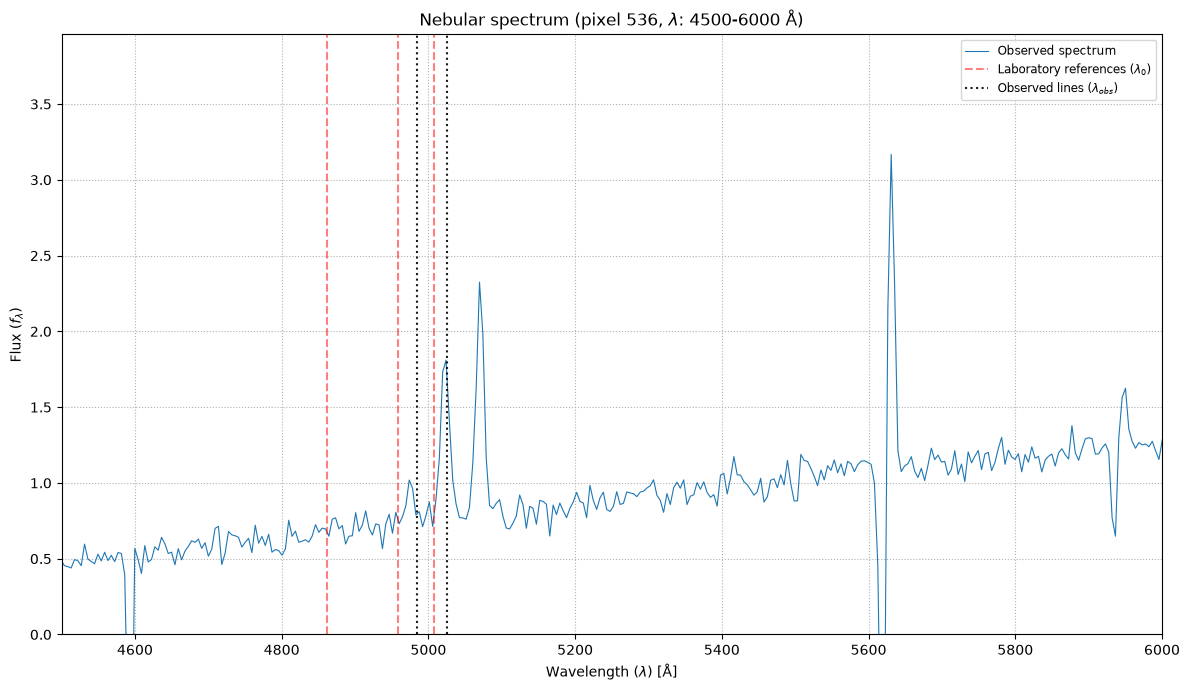

Plot saved: D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion\spectrum_pixel_536_6000-7500.png


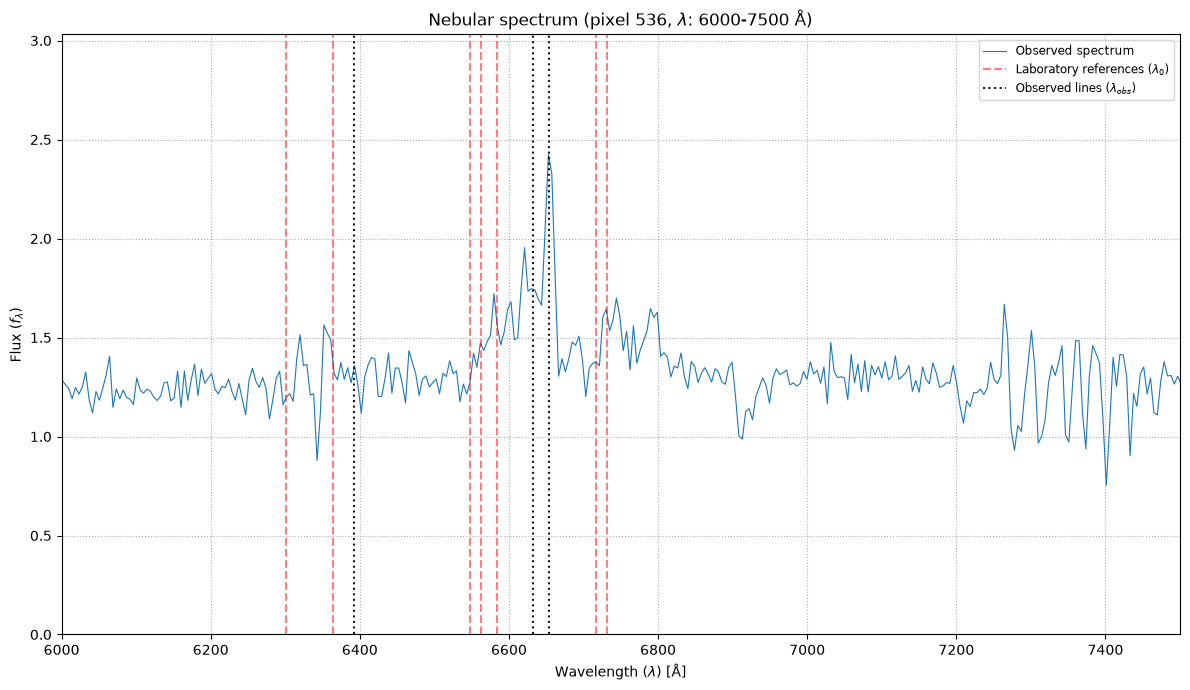


RADIAL-VELOCITY CALCULATION (Pixel 536)
Individual velocities [km/s]:
  O_III_2 : v = 1511.36 ± 302.27
  O_III   : v = 1077.74 ± 299.37
  O_I_2   : v = 1319.05 ± 235.55
  H_alpha : v = 3197.64 ± 228.40
  N_II_2  : v = 3187.63 ± 227.69

--------------------------------------------------
Number of lines used: 5
Weighted mean radial velocity:
V_radial = 2228.47 ± 112.81 km/s
--------------------------------------------------

Final result for pixel 536: V_radial = (2228.47 ± 112.81) km/s

Velocity data updated in the global list 'VELOCIDADES_POR_PIXEL'.


In [50]:
import os

try:
    PIXEL_CENTRAL = 536
except NameError:
    PIXEL_CENTRAL = 536

# Output directory for saved plots
RUTA_BASE_DESEADA = r"D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion"
os.makedirs(RUTA_BASE_DESEADA, exist_ok=True)
GRAFICOS_OUTPUT_DIR = RUTA_BASE_DESEADA

# Constants
C_LIGHT = 299792.458  # Speed of light in km/s

LINEAS_LAB = {
    'H_beta': 4861.32,
    'O_III_2': 4959.0,
    'O_III': 5007.0,
    'O_I_1': 6300.3,
    'O_I_2': 6363.8,
    'N_II': 6548.1,
    'H_alpha': 6562.8,
    'N_II_2': 6583.4,
    'S_II_1': 6717.0,
    'S_II_2': 6731.0
}

rango_graficas = [ (4500, 6000), (6000, 7500) ]
UMBRAL_PROMINENCE = 5

# Manually measured wavelength shifts for this spatial region
DESPLAZAMIENTOS = {
    'H_beta': 0,
    'O_III_2': 25,
    'O_III': 18,
    'O_I_1': 0,
    'O_I_2': 28,
    'N_II': 0,
    'N_II_2': 70,
    'H_alpha': 70,
    'S_II_1': 0,
    'S_II_2': 0,
}

# Adopted uncertainty in the observed wavelength [Å]
ERROR_LAMBDA_OBS = 5.0

velocidades_individuales = []

for nombre, lambda_0 in LINEAS_LAB.items():
    if nombre in DESPLAZAMIENTOS:
        desplazamiento = DESPLAZAMIENTOS[nombre]

        if desplazamiento != 0:
            v = C_LIGHT * (desplazamiento / lambda_0)
            delta_v = C_LIGHT * (ERROR_LAMBDA_OBS / lambda_0)

            velocidades_individuales.append({
                'Elemento': nombre,
                'v': v,
                'Delta_v': delta_v
            })

for idx_graph, (rango_min, rango_max) in enumerate(rango_graficas):

    plt.figure(figsize=(12, 7))

    etiqueta_ref_usada = False
    ETIQUETA_UNICA_REF = r'Laboratory references ($\lambda_0$)'
    etiqueta_obs_usada = False
    ETIQUETA_UNICA_OBS = r'Observed lines ($\lambda_{obs}$)'

    try:
        idx_rango = np.where((wavelength_array >= rango_min) & (wavelength_array <= rango_max))

        if len(idx_rango[0]) == 0:
            plt.close()
            print(f"Warning: No data in the {rango_min}-{rango_max} Å range. Skipping plot.")
            continue

        max_y_rango = neb_spec_536[idx_rango]
        max_y_rango = np.max(max_y_rango)
        plt.plot(wavelength_array, neb_spec_536, label='Observed spectrum', linewidth=0.8)

    except NameError:
        print("ERROR: Required data variables are not defined. Stopping the plotting loop.")
        break

    for nombre, lambda_0 in LINEAS_LAB.items():
        if lambda_0 < rango_min or lambda_0 > rango_max:
            continue

        label_ref = ETIQUETA_UNICA_REF if not etiqueta_ref_usada else None
        plt.axvline(x=lambda_0, color='r', linestyle='--', alpha=0.5, label=label_ref)
        etiqueta_ref_usada = True

    for nombre, lambda_0 in LINEAS_LAB.items():
        if rango_min <= lambda_0 < rango_max and nombre in DESPLAZAMIENTOS:
            desplazamiento = DESPLAZAMIENTOS[nombre]

            if desplazamiento != 0:
                lambda_obs = lambda_0 + desplazamiento
                label_obs = ETIQUETA_UNICA_OBS if not etiqueta_obs_usada else None
                plt.axvline(x=lambda_obs, color='k', linestyle=':', linewidth=1.5,
                            alpha=0.9, label=label_obs)
                etiqueta_obs_usada = True

    plt.xlim([rango_min, rango_max])
    plt.ylim([0, max_y_rango * 1.25])
    titulo_plot = fr"Nebular spectrum (pixel {PIXEL_CENTRAL}, $\lambda$: {rango_min}-{rango_max} Å)"
    plt.title(titulo_plot)
    plt.xlabel(r"Wavelength ($\lambda$) [Å]")
    plt.ylabel(r"Flux ($f_{\lambda}$)")
    plt.grid(True, linestyle=':')
    plt.legend(loc='upper right', fontsize='small')
    plt.tight_layout(rect=[0, 0, 1, 1])

    nombre_archivo = f"spectrum_pixel_{PIXEL_CENTRAL}_{rango_min}-{rango_max}.png"
    ruta_guardado_png = os.path.join(GRAFICOS_OUTPUT_DIR, nombre_archivo)
    plt.savefig(ruta_guardado_png, dpi=300)
    print(f"Plot saved: {ruta_guardado_png}")
    plt.show()
    plt.close()

print("\n" + "="*70)
print(f"RADIAL-VELOCITY CALCULATION (Pixel {PIXEL_CENTRAL})")
print("="*70)

if not velocidades_individuales:
    print("Warning: No shifted lines were found for the radial-velocity calculation.")
else:
    v_array = np.array([item['v'] for item in velocidades_individuales])
    dv_array = np.array([item['Delta_v'] for item in velocidades_individuales])

    weights = 1 / dv_array**2
    v_media_ponderada = np.sum(v_array * weights) / np.sum(weights)
    delta_v_media = np.sqrt(1 / np.sum(weights))

    nueva_entrada = {
        'Pixel_Central': PIXEL_CENTRAL,
        'V_Media': v_media_ponderada,
        'Delta_V_Media': delta_v_media,
        'V_Lineas': {item['Elemento']: {'v': item['v'], 'Delta_v': item['Delta_v']}
                     for item in velocidades_individuales}
    }

    indices_a_eliminar = []
    for i, entrada in enumerate(VELOCIDADES_POR_PIXEL):
        if entrada['Pixel_Central'] == PIXEL_CENTRAL:
            indices_a_eliminar.append(i)

    for i in sorted(indices_a_eliminar, reverse=True):
        del VELOCIDADES_POR_PIXEL[i]

    VELOCIDADES_POR_PIXEL.append(nueva_entrada)

    print("Individual velocities [km/s]:")
    for item in velocidades_individuales:
        print(f"  {item['Elemento']:<8}: v = {item['v']:.2f} ± {item['Delta_v']:.2f}")

    print("\n" + "-"*50)
    print(f"Number of lines used: {len(v_array)}")
    print("Weighted mean radial velocity:")
    print(f"V_radial = {v_media_ponderada:.2f} ± {delta_v_media:.2f} km/s")
    print("-"*50)

    print(f"\nFinal result for pixel {PIXEL_CENTRAL}: V_radial = "
          f"({v_media_ponderada:.2f} ± {delta_v_media:.2f}) km/s")

    print("\nVelocity data updated in the global list 'VELOCIDADES_POR_PIXEL'.")


### Region 7


In [51]:
neb_spec_596 = neb_spec_red[:,596:602]
sky_spec_6 = neb_spec_red[:,1000:1006]
sky_spec_6 = np.sum(sky_spec_6, axis=1)
neb_spec_596 = np.sum(neb_spec_596,axis=1)
neb_spec_596 = neb_spec_596 - sky_spec_6


Plot saved: D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion\spectrum_pixel_596_4500-6000.png


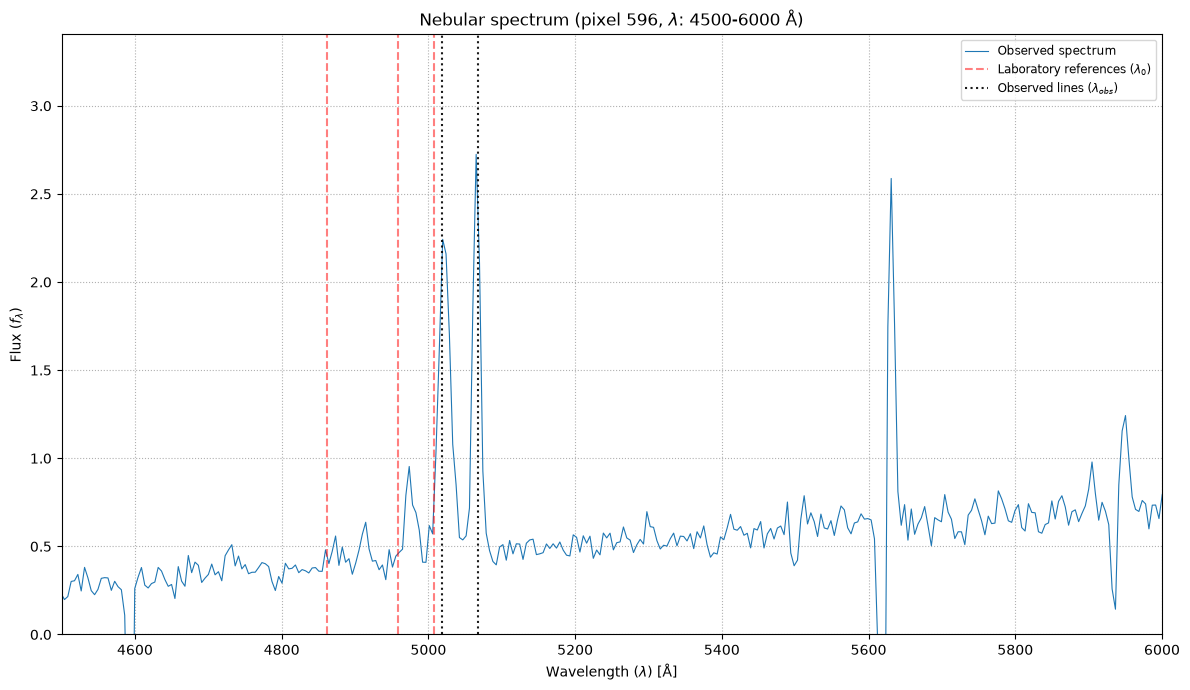

Plot saved: D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion\spectrum_pixel_596_6000-7500.png


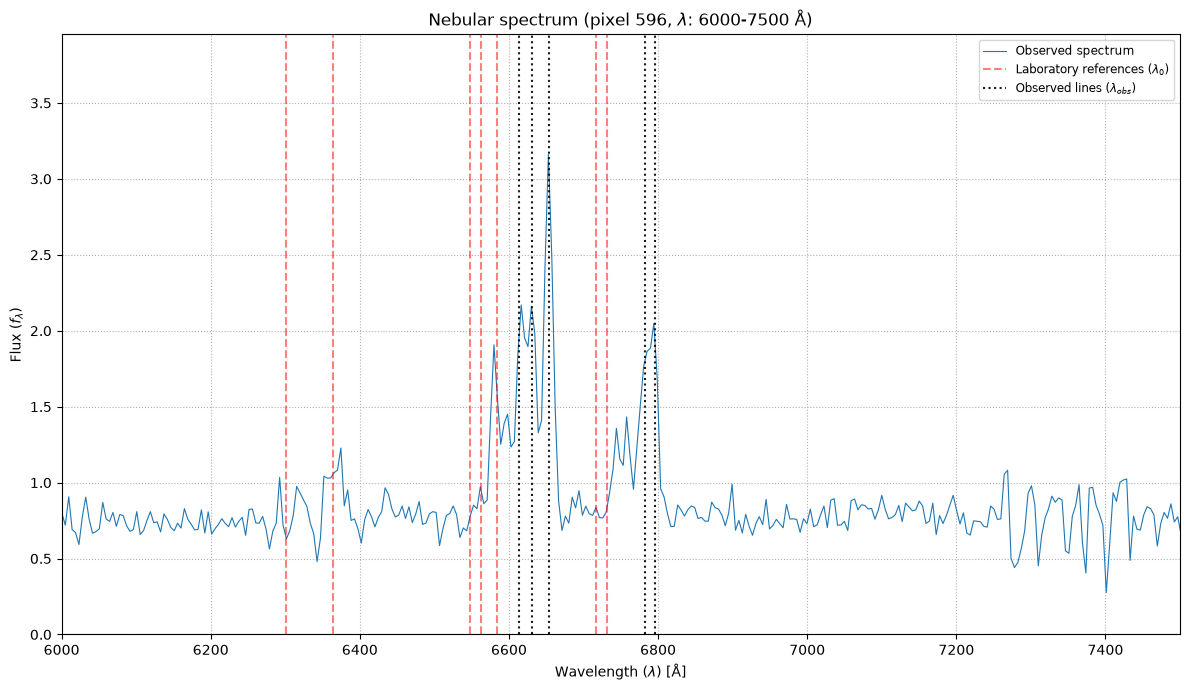


RADIAL-VELOCITY CALCULATION (Pixel 596)
Individual velocities [km/s]:
  O_III_2 : v = 3627.25 ± 302.27
  O_III   : v = 3592.48 ± 299.37
  N_II    : v = 2975.90 ± 228.92
  H_alpha : v = 3106.28 ± 228.40
  N_II_2  : v = 3187.63 ± 227.69
  S_II_1  : v = 2901.07 ± 223.16
  S_II_2  : v = 2895.04 ± 222.70

--------------------------------------------------
Number of lines used: 7
Weighted mean radial velocity:
V_radial = 3121.53 ± 91.33 km/s
--------------------------------------------------

Final result for pixel 596: V_radial = (3121.53 ± 91.33) km/s

Velocity data updated in the global list 'VELOCIDADES_POR_PIXEL'.


In [52]:
import os

try:
    PIXEL_CENTRAL = 596
except NameError:
    PIXEL_CENTRAL = 596

# Output directory for saved plots
RUTA_BASE_DESEADA = r"D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion"
os.makedirs(RUTA_BASE_DESEADA, exist_ok=True)
GRAFICOS_OUTPUT_DIR = RUTA_BASE_DESEADA

# Constants
C_LIGHT = 299792.458  # Speed of light in km/s

LINEAS_LAB = {
    'H_beta': 4861.32,
    'O_III_2': 4959.0,
    'O_III': 5007.0,
    'O_I_1': 6300.3,
    'O_I_2': 6363.8,
    'N_II': 6548.1,
    'H_alpha': 6562.8,
    'N_II_2': 6583.4,
    'S_II_1': 6717.0,
    'S_II_2': 6731.0
}

rango_graficas = [ (4500, 6000), (6000, 7500) ]
UMBRAL_PROMINENCE = 5

# Manually measured wavelength shifts for this spatial region
DESPLAZAMIENTOS = {
    'H_beta': 0,
    'O_III_2': 60,
    'O_III': 60,
    'O_I_1': 0,
    'O_I_2': 0,
    'N_II': 65,
    'N_II_2': 70,
    'H_alpha': 68,
    'S_II_1': 65,
    'S_II_2': 65,
}

# Adopted uncertainty in the observed wavelength [Å]
ERROR_LAMBDA_OBS = 5.0

velocidades_individuales = []

for nombre, lambda_0 in LINEAS_LAB.items():
    if nombre in DESPLAZAMIENTOS:
        desplazamiento = DESPLAZAMIENTOS[nombre]

        if desplazamiento != 0:
            v = C_LIGHT * (desplazamiento / lambda_0)
            delta_v = C_LIGHT * (ERROR_LAMBDA_OBS / lambda_0)

            velocidades_individuales.append({
                'Elemento': nombre,
                'v': v,
                'Delta_v': delta_v
            })

for idx_graph, (rango_min, rango_max) in enumerate(rango_graficas):

    plt.figure(figsize=(12, 7))

    etiqueta_ref_usada = False
    ETIQUETA_UNICA_REF = r'Laboratory references ($\lambda_0$)'
    etiqueta_obs_usada = False
    ETIQUETA_UNICA_OBS = r'Observed lines ($\lambda_{obs}$)'

    try:
        idx_rango = np.where((wavelength_array >= rango_min) & (wavelength_array <= rango_max))

        if len(idx_rango[0]) == 0:
            plt.close()
            print(f"Warning: No data in the {rango_min}-{rango_max} Å range. Skipping plot.")
            continue

        max_y_rango = neb_spec_596[idx_rango]
        max_y_rango = np.max(max_y_rango)
        plt.plot(wavelength_array, neb_spec_596, label='Observed spectrum', linewidth=0.8)

    except NameError:
        print("ERROR: Required data variables are not defined. Stopping the plotting loop.")
        break

    for nombre, lambda_0 in LINEAS_LAB.items():
        if lambda_0 < rango_min or lambda_0 > rango_max:
            continue

        label_ref = ETIQUETA_UNICA_REF if not etiqueta_ref_usada else None
        plt.axvline(x=lambda_0, color='r', linestyle='--', alpha=0.5, label=label_ref)
        etiqueta_ref_usada = True

    for nombre, lambda_0 in LINEAS_LAB.items():
        if rango_min <= lambda_0 < rango_max and nombre in DESPLAZAMIENTOS:
            desplazamiento = DESPLAZAMIENTOS[nombre]

            if desplazamiento != 0:
                lambda_obs = lambda_0 + desplazamiento
                label_obs = ETIQUETA_UNICA_OBS if not etiqueta_obs_usada else None
                plt.axvline(x=lambda_obs, color='k', linestyle=':', linewidth=1.5,
                            alpha=0.9, label=label_obs)
                etiqueta_obs_usada = True

    plt.xlim([rango_min, rango_max])
    plt.ylim([0, max_y_rango * 1.25])
    titulo_plot = fr"Nebular spectrum (pixel {PIXEL_CENTRAL}, $\lambda$: {rango_min}-{rango_max} Å)"
    plt.title(titulo_plot)
    plt.xlabel(r"Wavelength ($\lambda$) [Å]")
    plt.ylabel(r"Flux ($f_{\lambda}$)")
    plt.grid(True, linestyle=':')
    plt.legend(loc='upper right', fontsize='small')
    plt.tight_layout(rect=[0, 0, 1, 1])

    nombre_archivo = f"spectrum_pixel_{PIXEL_CENTRAL}_{rango_min}-{rango_max}.png"
    ruta_guardado_png = os.path.join(GRAFICOS_OUTPUT_DIR, nombre_archivo)
    plt.savefig(ruta_guardado_png, dpi=300)
    print(f"Plot saved: {ruta_guardado_png}")
    plt.show()
    plt.close()

print("\n" + "="*70)
print(f"RADIAL-VELOCITY CALCULATION (Pixel {PIXEL_CENTRAL})")
print("="*70)

if not velocidades_individuales:
    print("Warning: No shifted lines were found for the radial-velocity calculation.")
else:
    v_array = np.array([item['v'] for item in velocidades_individuales])
    dv_array = np.array([item['Delta_v'] for item in velocidades_individuales])

    weights = 1 / dv_array**2
    v_media_ponderada = np.sum(v_array * weights) / np.sum(weights)
    delta_v_media = np.sqrt(1 / np.sum(weights))

    nueva_entrada = {
        'Pixel_Central': PIXEL_CENTRAL,
        'V_Media': v_media_ponderada,
        'Delta_V_Media': delta_v_media,
        'V_Lineas': {item['Elemento']: {'v': item['v'], 'Delta_v': item['Delta_v']}
                     for item in velocidades_individuales}
    }

    indices_a_eliminar = []
    for i, entrada in enumerate(VELOCIDADES_POR_PIXEL):
        if entrada['Pixel_Central'] == PIXEL_CENTRAL:
            indices_a_eliminar.append(i)

    for i in sorted(indices_a_eliminar, reverse=True):
        del VELOCIDADES_POR_PIXEL[i]

    VELOCIDADES_POR_PIXEL.append(nueva_entrada)

    print("Individual velocities [km/s]:")
    for item in velocidades_individuales:
        print(f"  {item['Elemento']:<8}: v = {item['v']:.2f} ± {item['Delta_v']:.2f}")

    print("\n" + "-"*50)
    print(f"Number of lines used: {len(v_array)}")
    print("Weighted mean radial velocity:")
    print(f"V_radial = {v_media_ponderada:.2f} ± {delta_v_media:.2f} km/s")
    print("-"*50)

    print(f"\nFinal result for pixel {PIXEL_CENTRAL}: V_radial = "
          f"({v_media_ponderada:.2f} ± {delta_v_media:.2f}) km/s")

    print("\nVelocity data updated in the global list 'VELOCIDADES_POR_PIXEL'.")


## Radial Velocity by Emission Line



Velocity-by-line plot saved: D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion\Velocity_Lines_vs_Position_arcsec.png


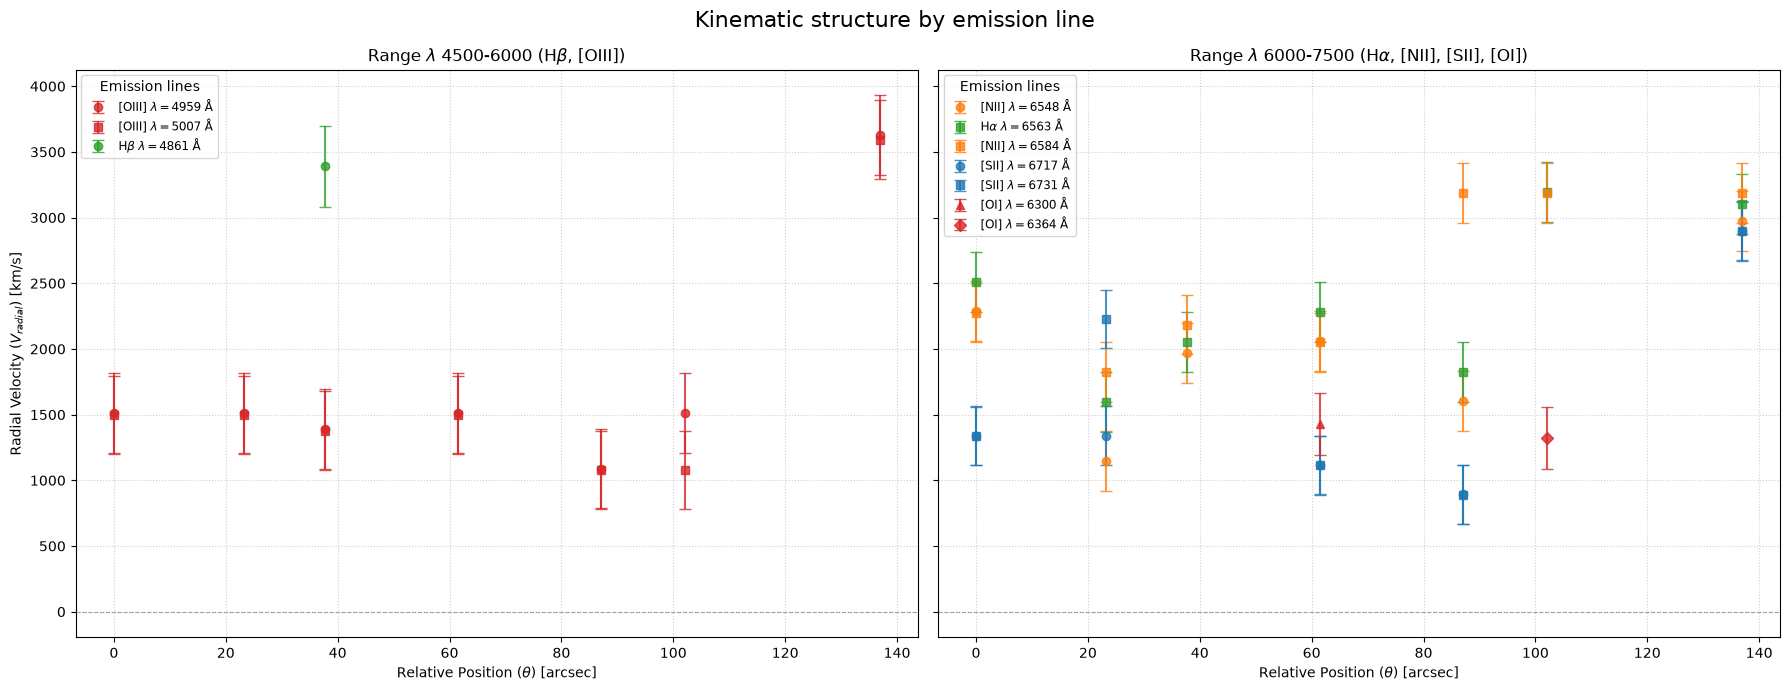

In [53]:
import os

if 'VELOCIDADES_POR_PIXEL' not in globals():
    VELOCIDADES_POR_PIXEL = []

FACTOR_CONVERSION_ARCSEC = 0.58

RUTA_BASE_DESEADA = r"D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion"
os.makedirs(RUTA_BASE_DESEADA, exist_ok=True)
GRAFICOS_OUTPUT_DIR = RUTA_BASE_DESEADA

RANGO_PLOT_1 = (4500, 6000)
RANGO_PLOT_2 = (6000, 7500)

LINEAS_LAB = {
    'H_beta': 4861.32,
    'O_III_2': 4959.0,
    'O_III': 5007.0,
    'O_I_1': 6300.3,
    'O_I_2': 6363.8,
    'N_II': 6548.1,
    'H_alpha': 6562.8,
    'N_II_2': 6583.4,
    'S_II_1': 6717.0,
    'S_II_2': 6731.0
}

LINEAS_ETIQUETAS = {
    'H_beta': r"H$\beta\ \lambda = 4861\ \text{Å}$",
    'O_III_2': r"[OIII] $\lambda = 4959\ \text{Å}$",
    'O_III': r"[OIII] $\lambda = 5007\ \text{Å}$",
    'O_I_1': r"[OI] $\lambda = 6300\ \text{Å}$",
    'O_I_2': r"[OI] $\lambda = 6364\ \text{Å}$",
    'N_II': r"[NII] $\lambda = 6548\ \text{Å}$",
    'H_alpha': r"H$\alpha\ \lambda = 6563\ \text{Å}$",
    'N_II_2': r"[NII] $\lambda = 6584\ \text{Å}$",
    'S_II_1': r"[SII] $\lambda = 6717\ \text{Å}$",
    'S_II_2': r"[SII] $\lambda = 6731\ \text{Å}$"
}

COLOR_MAP_GRUPOS = {
    'H': '#2ca02c',
    'O': '#d62728',
    'N': '#ff7f0e',
    'S': '#1f77b4',
}

COLOR_LINEAS = {}
MARCADOR_LINEAS = {}
MARCADORES = ['o', 's', '^', 'D', 'p', 'v']

def get_line_prefix(line_name):
    if line_name.startswith('H'):
        return 'H'
    elif line_name.startswith('O'):
        return 'O'
    elif line_name.startswith('N'):
        return 'N'
    elif line_name.startswith('S'):
        return 'S'
    return None

marcadores_usados = {group: 0 for group in COLOR_MAP_GRUPOS.keys()}

for line_name in LINEAS_LAB.keys():
    prefix = get_line_prefix(line_name)
    if prefix:
        COLOR_LINEAS[line_name] = COLOR_MAP_GRUPOS[prefix]
        idx = marcadores_usados[prefix] % len(MARCADORES)
        MARCADOR_LINEAS[line_name] = MARCADORES[idx]
        marcadores_usados[prefix] += 1
    else:
        COLOR_LINEAS[line_name] = '#9467bd'
        MARCADOR_LINEAS[line_name] = 'x'

datos_por_elemento = {}
nombres_elementos_registrados = set()
PIXEL_ORIGEN = 0

if VELOCIDADES_POR_PIXEL:
    pixels_ordenados = sorted([d['Pixel_Central'] for d in VELOCIDADES_POR_PIXEL])
    PIXEL_ORIGEN = pixels_ordenados[0] if pixels_ordenados else 0

    for entrada in VELOCIDADES_POR_PIXEL:
        pixel = entrada['Pixel_Central']
        posicion_arcsec = (pixel - PIXEL_ORIGEN) * FACTOR_CONVERSION_ARCSEC

        for elemento, datos_v in entrada['V_Lineas'].items():
            if elemento not in datos_por_elemento:
                datos_por_elemento[elemento] = {
                    'posiciones': [],
                    'velocidades': [],
                    'errores': [],
                    'lambda_0': LINEAS_LAB.get(elemento, 0)
                }

            datos_por_elemento[elemento]['posiciones'].append(posicion_arcsec)
            datos_por_elemento[elemento]['velocidades'].append(datos_v['v'])
            datos_por_elemento[elemento]['errores'].append(datos_v['Delta_v'])
else:
    print("No velocity data available for plotting.")

if datos_por_elemento:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

    ax1 = axes[0]
    ax2 = axes[1]

    for elemento, datos in datos_por_elemento.items():
        if not datos['velocidades']:
            continue

        pos = np.array(datos['posiciones'])
        vel = np.array(datos['velocidades'])
        err = np.array(datos['errores'])
        lambda_0 = datos['lambda_0']

        color_asignado = COLOR_LINEAS.get(elemento, 'black')
        marcador_asignado = MARCADOR_LINEAS.get(elemento, 'x')

        if RANGO_PLOT_1[0] <= lambda_0 <= RANGO_PLOT_1[1]:
            ax = ax1
        elif RANGO_PLOT_2[0] <= lambda_0 <= RANGO_PLOT_2[1]:
            ax = ax2
        else:
            continue

        ax.errorbar(
            pos,
            vel,
            yerr=err,
            fmt=marcador_asignado,
            linestyle='',
            color=color_asignado,
            capsize=4,
            label=LINEAS_ETIQUETAS.get(elemento, elemento),
            alpha=0.8,
            linewidth=1.5
        )

    ax1.set_title(r"Range $\lambda$ 4500-6000 ($\mathrm{H}\beta$, [OIII])")
    ax1.set_xlabel(r"Relative Position ($\theta$) [arcsec]")
    ax1.set_ylabel(r"Radial Velocity ($V_{radial}$) [km/s]")
    ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(title="Emission lines", loc='upper left', fontsize='small')

    ax2.set_title(r"Range $\lambda$ 6000-7500 ($\mathrm{H}\alpha$, [NII], [SII], [OI])")
    ax2.set_xlabel(r"Relative Position ($\theta$) [arcsec]")
    ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(title="Emission lines", loc='upper left', fontsize='small')

    fig.suptitle("Kinematic structure by emission line", fontsize=16)
    plt.tight_layout()

    nombre_archivo = "Velocity_Lines_vs_Position_arcsec.png"
    ruta_guardado_png = os.path.join(GRAFICOS_OUTPUT_DIR, nombre_archivo)
    plt.savefig(ruta_guardado_png, dpi=300)
    print(f"\nVelocity-by-line plot saved: {ruta_guardado_png}")

    plt.show()
    plt.close()


## Mean Radial Velocity



Mean radial-velocity plot saved: D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion\Mean_Velocity_vs_Position_arcsec_no_fit.png


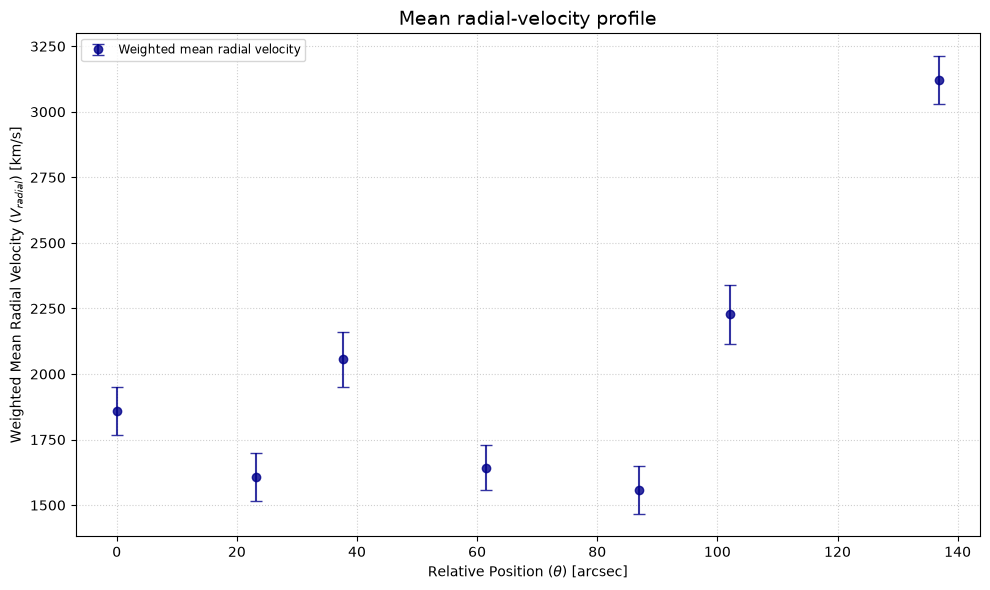

In [54]:
import os

FACTOR_CONVERSION_ARCSEC = 0.58

RUTA_BASE_DESEADA = r"D:\Documents\Grado en física\IV\TEA\Proyecto\M1\Picos_espectro_por_posicion"
os.makedirs(RUTA_BASE_DESEADA, exist_ok=True)
GRAFICOS_OUTPUT_DIR = RUTA_BASE_DESEADA

posiciones_arcsec = []
velocidades_medias = []
errores_medias = []

if 'VELOCIDADES_POR_PIXEL' not in globals() or not VELOCIDADES_POR_PIXEL:
    print("ERROR: 'VELOCIDADES_POR_PIXEL' is empty or not defined.")
else:
    pixels_ordenados = sorted([d['Pixel_Central'] for d in VELOCIDADES_POR_PIXEL])
    PIXEL_ORIGEN = pixels_ordenados[0] if pixels_ordenados else 0

    for entrada in VELOCIDADES_POR_PIXEL:
        pixel = entrada['Pixel_Central']
        posicion_arcsec = (pixel - PIXEL_ORIGEN) * FACTOR_CONVERSION_ARCSEC
        posiciones_arcsec.append(posicion_arcsec)
        velocidades_medias.append(entrada['V_Media'])
        errores_medias.append(entrada['Delta_V_Media'])

pos_array = np.array(posiciones_arcsec)
vel_media_array = np.array(velocidades_medias)
err_media_array = np.array(errores_medias)

if len(pos_array) > 0:
    plt.figure(figsize=(10, 6))

    plt.errorbar(
        pos_array,
        vel_media_array,
        yerr=err_media_array,
        fmt='o',
        color='darkblue',
        capsize=4,
        label='Weighted mean radial velocity',
        alpha=0.8,
        linewidth=1.5
    )

    plt.title("Mean radial-velocity profile", fontsize=14)
    plt.xlabel(r"Relative Position ($\theta$) [arcsec]")
    plt.ylabel(r"Weighted Mean Radial Velocity ($V_{radial}$) [km/s]")

    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left', fontsize='small')
    plt.tight_layout()

    nombre_archivo = "Mean_Velocity_vs_Position_arcsec_no_fit.png"
    ruta_guardado_png = os.path.join(GRAFICOS_OUTPUT_DIR, nombre_archivo)
    plt.savefig(ruta_guardado_png, dpi=300)
    print(f"\nMean radial-velocity plot saved: {ruta_guardado_png}")

    plt.show()
    plt.close()
else:
    print("Warning: The mean radial-velocity plot could not be generated because the arrays are empty.")
